# **TFM - SESGOS DEMOGRAFICOS**

## **LIBRERÍAS**

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from matplotlib.ticker import FuncFormatter
from scipy.stats import mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint, uniform
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix, recall_score, precision_score, f1_score, balanced_accuracy_score, accuracy_score, brier_score_loss
from sklearn.metrics import precision_recall_curve
import fairlearn
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import equalized_odds_difference
import joblib
import os


pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="white")

## **CARGA DE DATOS**

In [33]:
# Carga de la base de clientes de tarjetas de crédito
datos = pd.read_excel("C:/Users/DIANA/OneDrive/Escritorio/Maestria/TFM/default of credit card clients.xlsx", header=1)
datos.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [34]:
# Dimensiones y variables de la base
print("Número de filas:", datos.shape[0])
print("Número de columnas:", datos.shape[1])

print("\nVariables:")
print(datos.columns.tolist())

Número de filas: 30000
Número de columnas: 25

Variables:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [35]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [36]:
# ----------------- RECODIFICACIÓN DE VARIABLES ----------------- #
# Se reemplazan los códigos originales de las variables demográficas, por categorías descriptivas para facilitar su análisis e interpretación.

datos["SEX"] = datos["SEX"].map({
    1: "Hombre",
    2: "Mujer"
})

datos["EDUCATION"] = datos["EDUCATION"].map({
    0: "No especificado",
    1: "Posgrado",
    2: "Universidad",
    3: "Secundaria",
    4: "Otros",
    5: "No especificado",
    6: "No especificado"
})

datos["MARRIAGE"] = datos["MARRIAGE"].map({
    0: "No especificado",
    1: "Casado/a",
    2: "Soltero/a",
    3: "Otros"
})

## **EDA**

### **Variable objetivo**

In [37]:
target = "default payment next month"

resumen_target = (datos[target].value_counts().sort_index().rename_axis("Target").reset_index(name="Cantidad"))
resumen_target["Porcentaje"] = (resumen_target["Cantidad"] / len(datos) * 100)

resumen_target["Grupo"] = resumen_target["Target"].map({
    0: "No incumplimiento",
    1: "Incumplimiento"
})

print(resumen_target)

   Target  Cantidad  Porcentaje              Grupo
0       0     23364       77.88  No incumplimiento
1       1      6636       22.12     Incumplimiento


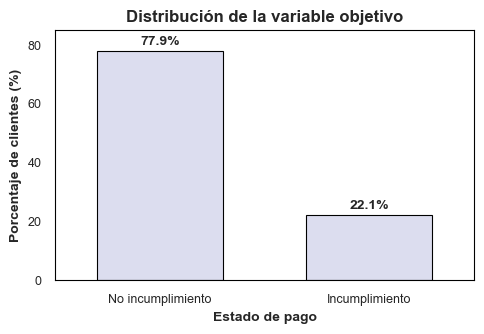

In [38]:
# Distribución porcentual de la variable objetivo

plt.figure(figsize=(5, 3.5))

ax = sns.barplot(data=resumen_target, x="Grupo", y="Porcentaje", color="#D9DAF2", edgecolor="black", linewidth=0.8, width=0.6)

for barra, porcentaje in zip(ax.patches, resumen_target["Porcentaje"]):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 1, f"{porcentaje:.1f}%", 
            ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Distribución de la variable objetivo", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Estado de pago", fontsize=10, fontweight="bold")
plt.ylabel("Porcentaje de clientes (%)", fontsize=10, fontweight="bold")

ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.ylim(0, 85)
plt.tight_layout()
plt.show()

### **Perfil del cliente**

In [39]:
# ------------------------------ SEXO ------------------------------ #

resumen_sexo = (datos["SEX"].value_counts().rename_axis("Sexo").reset_index(name="Cantidad"))
resumen_sexo["Porcentaje"] = (resumen_sexo["Cantidad"] / len(datos) * 100)
print("\n Resumen por sexo:")
print(resumen_sexo)

incumplimiento_sexo = (datos.groupby("SEX")["default payment next month"].agg(
        Clientes="count",
        Incumplimientos="sum",
        Tasa_incumplimiento="mean"
    ).reset_index())

incumplimiento_sexo["Tasa_incumplimiento"] = ((incumplimiento_sexo["Tasa_incumplimiento"] * 100).round(2))
print("\n Incumplimiento por sexo:")
print(incumplimiento_sexo)


 Resumen por sexo:
     Sexo  Cantidad  Porcentaje
0   Mujer     18112       60.37
1  Hombre     11888       39.63

 Incumplimiento por sexo:
      SEX  Clientes  Incumplimientos  Tasa_incumplimiento
0  Hombre     11888             2873                24.17
1   Mujer     18112             3763                20.78


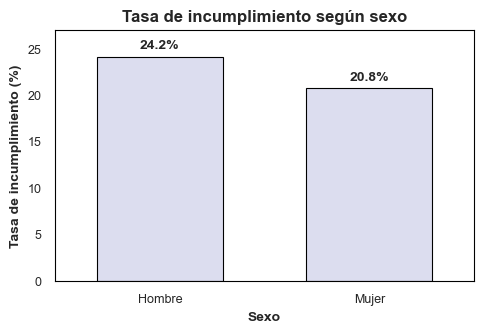

In [40]:
plt.figure(figsize=(5, 3.5))

ax = sns.barplot(data=incumplimiento_sexo, x="SEX", y="Tasa_incumplimiento", color="#D9DAF2", edgecolor="black", linewidth=0.8, width=0.6)
for barra, porcentaje in zip(ax.patches, incumplimiento_sexo["Tasa_incumplimiento"]):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.5, f"{porcentaje:.1f}%",
    ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Tasa de incumplimiento según sexo", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Sexo", fontsize=10, fontweight="bold")
plt.ylabel("Tasa de incumplimiento (%)", fontsize=10, fontweight="bold")

ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 27)
plt.tight_layout()
plt.show()

In [41]:
# ----------- PRUEBA CHI-CUADRADO: SEXO VS INCUMPLIMIENTO ----------- #

tabla_sexo_target = pd.crosstab(datos["SEX"], datos["default payment next month"])
print("Tabla de contingencia:")
print(tabla_sexo_target)

# Prueba de independencia Chi-cuadrado
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_sexo_target)
print("\nResultados prueba Chi-cuadrado:")
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Grados de libertad: {grados_libertad}")

# Tamaño del efecto mediante V de Cramér
n = tabla_sexo_target.to_numpy().sum()
filas, columnas = tabla_sexo_target.shape
v_cramer = np.sqrt(chi2 / (n * min(filas - 1, columnas - 1)))
print(f"V de Cramér: {v_cramer:.4f}")

Tabla de contingencia:
default payment next month      0     1
SEX                                    
Hombre                       9015  2873
Mujer                       14349  3763

Resultados prueba Chi-cuadrado:
Chi-cuadrado: 47.7088
p-valor: 0.000000
Grados de libertad: 1
V de Cramér: 0.0399


In [42]:
# ------------------------- NIVEL EDUCATIVO ------------------------#

resumen_educacion = (datos["EDUCATION"].value_counts().rename_axis("Educacion").reset_index(name="Cantidad"))
resumen_educacion["Porcentaje"] = (resumen_educacion["Cantidad"] / len(datos) * 100)
print("Resumen por nivel educativo:")
print(resumen_educacion)

incumplimiento_educacion = (datos.groupby("EDUCATION")["default payment next month"].agg(
        Clientes="count",
        Incumplimientos="sum",
        Tasa_incumplimiento="mean"
    ).reset_index())

incumplimiento_educacion["Tasa_incumplimiento"] = ((incumplimiento_educacion["Tasa_incumplimiento"] * 100).round(2))
incumplimiento_educacion = incumplimiento_educacion.sort_values("Tasa_incumplimiento", ascending=False)
print("\n Incumplimiento por nivel educativo:")
print(incumplimiento_educacion)

Resumen por nivel educativo:
         Educacion  Cantidad  Porcentaje
0      Universidad     14030       46.77
1         Posgrado     10585       35.28
2       Secundaria      4917       16.39
3  No especificado       345        1.15
4            Otros       123        0.41

 Incumplimiento por nivel educativo:
         EDUCATION  Clientes  Incumplimientos  Tasa_incumplimiento
3       Secundaria      4917             1237                25.16
4      Universidad     14030             3330                23.73
2         Posgrado     10585             2036                19.23
0  No especificado       345               26                 7.54
1            Otros       123                7                 5.69


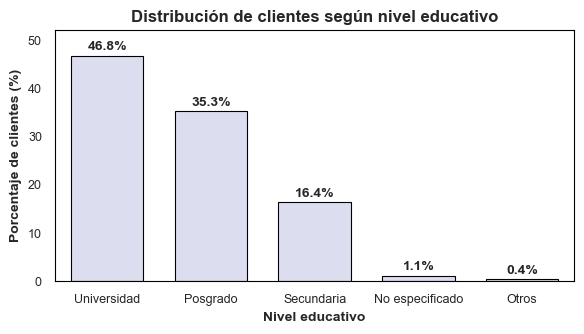

In [43]:
resumen_educacion = resumen_educacion.sort_values("Porcentaje",ascending=False)
plt.figure(figsize=(6, 3.5))

ax = sns.barplot(data=resumen_educacion, x="Educacion", y="Porcentaje", color="#D9DAF2", edgecolor="black", linewidth=0.8, width=0.7)
for barra, porcentaje in zip(ax.patches, resumen_educacion["Porcentaje"]):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.5, f"{porcentaje:.1f}%",
    ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Distribución de clientes según nivel educativo", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Nivel educativo", fontsize=10, fontweight="bold")
plt.ylabel("Porcentaje de clientes (%)", fontsize=10, fontweight="bold")

ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 52)
plt.tight_layout()
plt.show()


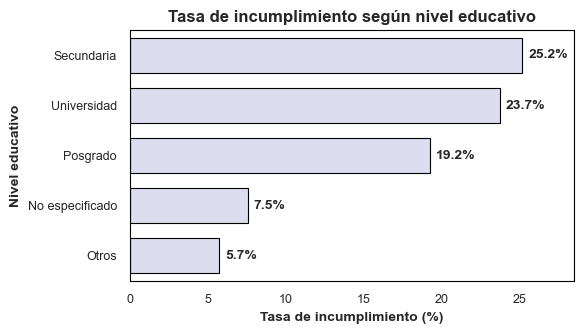

In [44]:
plt.figure(figsize=(6, 3.5))

ax = sns.barplot(data=incumplimiento_educacion, y="EDUCATION", x="Tasa_incumplimiento", color="#D9DAF2", edgecolor="black", linewidth=0.8, width=0.7)
for barra, porcentaje in zip(ax.patches, incumplimiento_educacion["Tasa_incumplimiento"]):
    ax.text(barra.get_width() + 0.4, barra.get_y() + barra.get_height() / 2, f"{porcentaje:.1f}%",
    va="center", fontsize=10, fontweight="bold")
    
plt.title("Tasa de incumplimiento según nivel educativo", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Tasa de incumplimiento (%)", fontsize=10, fontweight="bold")
plt.ylabel("Nivel educativo", fontsize=10, fontweight="bold")

ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlim(0, 28.5)
plt.tight_layout()
plt.show()

In [45]:
# --------- PRUEBA CHI-CUADRADO: EDUCACIÓN VS INCUMPLIMIENTO -------- #

tabla_educacion_target = pd.crosstab(datos["EDUCATION"], datos["default payment next month"])
print("Tabla de contingencia:")
print(tabla_educacion_target)

# Prueba de independencia Chi-cuadrado
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_educacion_target)
print("\nResultados prueba Chi-cuadrado:")
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Grados de libertad: {grados_libertad}")

# Tamaño del efecto mediante V de Cramér
n = tabla_educacion_target.to_numpy().sum()
filas, columnas = tabla_educacion_target.shape
v_cramer = np.sqrt(chi2 / (n * min(filas - 1, columnas - 1)))
print(f"V de Cramér: {v_cramer:.4f}")

Tabla de contingencia:
default payment next month      0     1
EDUCATION                              
No especificado               319    26
Otros                         116     7
Posgrado                     8549  2036
Secundaria                   3680  1237
Universidad                 10700  3330

Resultados prueba Chi-cuadrado:
Chi-cuadrado: 160.5892
p-valor: 0.000000
Grados de libertad: 4
V de Cramér: 0.0732


In [46]:
# -------------------------- ESTADO CIVIL --------------------------#

resumen_estado_civil = (datos["MARRIAGE"].value_counts().rename_axis("Estado_civil").reset_index(name="Cantidad"))
resumen_estado_civil["Porcentaje"] = ((resumen_estado_civil["Cantidad"] / len(datos) * 100).round(2))
print("Resumen por estado civil:")
print(resumen_estado_civil)

incumplimiento_estado_civil = (datos.groupby("MARRIAGE")["default payment next month"].agg(
        Clientes="count",
        Incumplimientos="sum",
        Tasa_incumplimiento="mean"
    ).reset_index())

incumplimiento_estado_civil["Tasa_incumplimiento"] = ((incumplimiento_estado_civil["Tasa_incumplimiento"] * 100).round(2))
incumplimiento_estado_civil = incumplimiento_estado_civil.sort_values("Tasa_incumplimiento", ascending=False)
print("\n Incumplimiento por estado civil:")
print(incumplimiento_estado_civil)

Resumen por estado civil:
      Estado_civil  Cantidad  Porcentaje
0        Soltero/a     15964       53.21
1         Casado/a     13659       45.53
2            Otros       323        1.08
3  No especificado        54        0.18

 Incumplimiento por estado civil:
          MARRIAGE  Clientes  Incumplimientos  Tasa_incumplimiento
2            Otros       323               84                26.01
0         Casado/a     13659             3206                23.47
3        Soltero/a     15964             3341                20.93
1  No especificado        54                5                 9.26


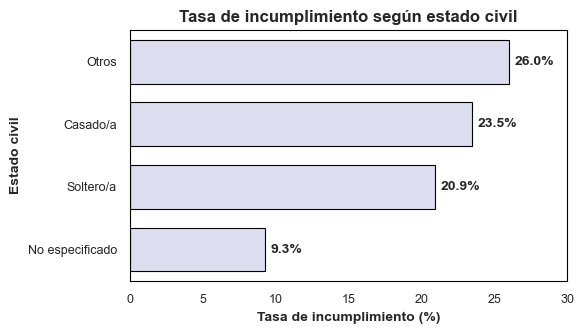

In [47]:
plt.figure(figsize=(6, 3.5))

ax = sns.barplot(data=incumplimiento_estado_civil, y="MARRIAGE", x="Tasa_incumplimiento", color="#D9DAF2", edgecolor="black", linewidth=0.8, width=0.7)
for barra, porcentaje in zip(ax.patches, incumplimiento_estado_civil["Tasa_incumplimiento"]):
    ax.text(barra.get_width() + 0.4, barra.get_y() + barra.get_height() / 2, f"{porcentaje:.1f}%",
    va="center", fontsize=10, fontweight="bold")

plt.title("Tasa de incumplimiento según estado civil",  fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Tasa de incumplimiento (%)", fontsize=10, fontweight="bold")
plt.ylabel("Estado civil", fontsize=10, fontweight="bold")

ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.xlim(0, 30)
plt.tight_layout()
plt.show()

In [48]:
# -------- PRUEBA CHI-CUADRADO: ESTADO CIVIL VS INCUMPLIMIENTO ------ #

tabla_estado_civil_target = pd.crosstab(datos["MARRIAGE"], datos["default payment next month"])
print("Tabla de contingencia:")
print(tabla_estado_civil_target)

# Prueba de independencia Chi-cuadrado
chi2, p_valor, grados_libertad, esperados = chi2_contingency(tabla_estado_civil_target)
print("\nResultados prueba Chi-cuadrado:")
print(f"Chi-cuadrado: {chi2:.4f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Grados de libertad: {grados_libertad}")

# Tamaño del efecto mediante V de Cramér
n = tabla_estado_civil_target.to_numpy().sum()
filas, columnas = tabla_estado_civil_target.shape
v_cramer = np.sqrt(chi2 / (n * min(filas - 1, columnas - 1)))
print(f"V de Cramér: {v_cramer:.4f}")

Tabla de contingencia:
default payment next month      0     1
MARRIAGE                               
Casado/a                    10453  3206
No especificado                49     5
Otros                         239    84
Soltero/a                   12623  3341

Resultados prueba Chi-cuadrado:
Chi-cuadrado: 35.6624
p-valor: 0.000000
Grados de libertad: 3
V de Cramér: 0.0345


In [49]:
# ------------------------- TABLA RESUMEN -------------------------  #
perfil_demografico = []

for variable in ["SEX", "EDUCATION", "MARRIAGE"]:
    resumen = datos.groupby(variable)["default payment next month"].agg(Clientes="count", Incumplimientos="sum", Tasa_incumplimiento="mean").reset_index()
    resumen["Porcentaje_muestra"] = resumen["Clientes"] / len(datos) * 100
    resumen["Tasa_incumplimiento"] = resumen["Tasa_incumplimiento"] * 100

    for _, fila in resumen.iterrows():
        perfil_demografico.append({
            "Variable": variable,
            "Categoria": fila[variable],
            "Clientes": fila["Clientes"],
            "Porcentaje_muestra": fila["Porcentaje_muestra"],
            "Tasa_incumplimiento": fila["Tasa_incumplimiento"]
        })

perfil_demografico = pd.DataFrame(perfil_demografico)
print(perfil_demografico.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

 Variable       Categoria  Clientes  Porcentaje_muestra  Tasa_incumplimiento
      SEX          Hombre     11888               39.63                24.17
      SEX           Mujer     18112               60.37                20.78
EDUCATION No especificado       345                1.15                 7.54
EDUCATION           Otros       123                0.41                 5.69
EDUCATION        Posgrado     10585               35.28                19.23
EDUCATION      Secundaria      4917               16.39                25.16
EDUCATION     Universidad     14030               46.77                23.73
 MARRIAGE        Casado/a     13659               45.53                23.47
 MARRIAGE No especificado        54                0.18                 9.26
 MARRIAGE           Otros       323                1.08                26.01
 MARRIAGE       Soltero/a     15964               53.21                20.93


In [50]:
# ------------------------------ EDAD ----------------------------- #

resumen_edad = datos["AGE"].describe()
print("Resumen por edad:")
print(resumen_edad)

resumen_edad_target = (datos.groupby("default payment next month")["AGE"].agg(
        Clientes="count",
        Edad_media="mean",
        Edad_mediana="median",
        Desviacion="std",
        Edad_minima="min",
        Edad_maxima="max"
    ).reset_index())

resumen_edad_target["Grupo"] = resumen_edad_target["default payment next month"].map({
    0: "No incumplimiento",
    1: "Incumplimiento"
})

resumen_edad_target[["Edad_media", "Edad_mediana", "Desviacion"]] = resumen_edad_target[["Edad_media", "Edad_mediana", "Desviacion"]].round(2)
print("\n Resumen de incumplimiento por edad:")
print(resumen_edad_target.to_string(index=False))

Resumen por edad:
count   30,000.00
mean        35.49
std          9.22
min         21.00
25%         28.00
50%         34.00
75%         41.00
max         79.00
Name: AGE, dtype: float64

 Resumen de incumplimiento por edad:
 default payment next month  Clientes  Edad_media  Edad_mediana  Desviacion  Edad_minima  Edad_maxima             Grupo
                          0     23364       35.42         34.00        9.08           21           79 No incumplimiento
                          1      6636       35.73         34.00        9.69           21           75    Incumplimiento


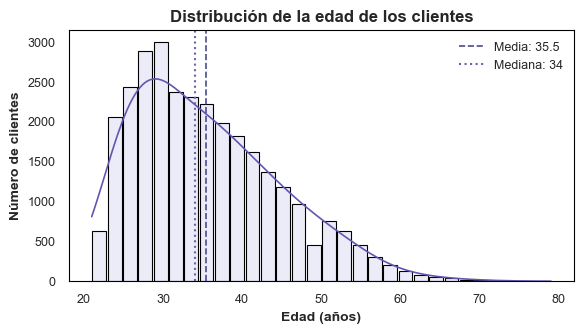

In [51]:
plt.figure(figsize=(6, 3.5))

ax = sns.histplot(data=datos, x="AGE", bins=30, kde=True, color="#D9DAF2", edgecolor="black", linewidth=0.8, shrink=0.9, kde_kws={"bw_adjust": 2.5})
ax.lines[0].set_color("#6256B2")
ax.lines[0].set_linewidth(1.2)

plt.axvline(datos["AGE"].mean(), linestyle="--", linewidth=1.2, color="#4B4B8F", label=f"Media: {datos['AGE'].mean():.1f}")
plt.axvline(datos["AGE"].median(), linestyle=":", linewidth=1.5, color="#6C63A8", label=f"Mediana: {datos['AGE'].median():.0f}")
plt.title("Distribución de la edad de los clientes", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Edad (años)", fontsize=10, fontweight="bold")
plt.ylabel("Número de clientes", fontsize=10, fontweight="bold")
plt.legend(frameon=False, fontsize=9)

ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [52]:
# ----------------------- LIMITE DE CREDITO ----------------------- #

resumen_limite = datos["LIMIT_BAL"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
print("Resumen por límite de crédito:")
print(resumen_limite)


resumen_limite_target = datos.groupby("default payment next month")["LIMIT_BAL"].agg(Clientes="count", Media="mean", Mediana="median", Desviacion="std", Minimo="min", Maximo="max").reset_index()
resumen_limite_target["Grupo"] = resumen_limite_target["default payment next month"].map({0: "No incumplimiento", 1: "Incumplimiento"})
resumen_limite_target[["Media", "Mediana", "Desviacion"]] = resumen_limite_target[["Media", "Mediana", "Desviacion"]].round(2)
print("\n Resumen de incumplimiento por límite de crédito:")
print(resumen_limite_target.to_string(index=False))

# Cuartiles del límite de crédito según incumplimiento
cuartiles_limite_target = datos.groupby("default payment next month")["LIMIT_BAL"].quantile([0.25, 0.50, 0.75]).unstack()
cuartiles_limite_target.columns = ["Q1", "Mediana", "Q3"]
print("\n Cuartiles de incumplimiento por límite de crédito:")
print(cuartiles_limite_target)

Resumen por límite de crédito:
count      30,000.00
mean      167,484.32
std       129,747.66
min        10,000.00
1%         10,000.00
5%         20,000.00
25%        50,000.00
50%       140,000.00
75%       240,000.00
95%       430,000.00
99%       500,000.00
max     1,000,000.00
Name: LIMIT_BAL, dtype: float64

 Resumen de incumplimiento por límite de crédito:
 default payment next month  Clientes      Media    Mediana  Desviacion  Minimo  Maximo             Grupo
                          0     23364 178,099.73 150,000.00  131,628.36   10000 1000000 No incumplimiento
                          1      6636 130,109.66  90,000.00  115,378.54   10000  740000    Incumplimiento

 Cuartiles de incumplimiento por límite de crédito:
                                  Q1    Mediana         Q3
default payment next month                                
0                          70,000.00 150,000.00 250,000.00
1                          50,000.00  90,000.00 200,000.00


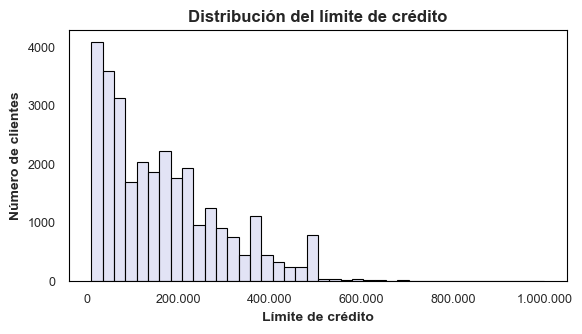

In [53]:
plt.figure(figsize=(6, 3.5))

ax = sns.histplot(data=datos, x="LIMIT_BAL", bins=40, color="#D9DAF2", edgecolor="black", linewidth=0.8, shrink=1)
plt.title("Distribución del límite de crédito", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Límite de crédito", fontsize=10, fontweight="bold")
plt.ylabel("Número de clientes", fontsize=10, fontweight="bold")

ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)    
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

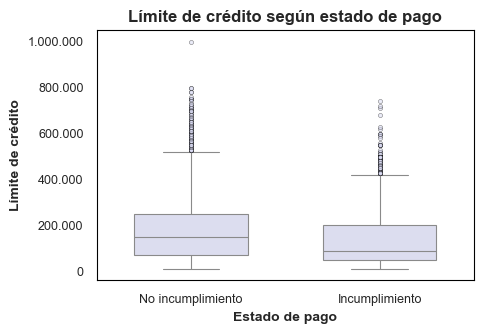

In [54]:
plt.figure(figsize=(5, 3.5))

ax = sns.boxplot(data=datos, x="default payment next month", y="LIMIT_BAL", color="#D9DAF2", linewidth=0.8, width=0.6, flierprops={"marker": "o", "markersize": 3, "markerfacecolor": "#D9DAF2", "markeredgecolor": "black", "markeredgewidth": 0.4, "alpha": 0.5})
plt.title("Límite de crédito según estado de pago", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Estado de pago", fontsize=10, fontweight="bold")
plt.ylabel("Límite de crédito", fontsize=10, fontweight="bold")
plt.xticks([0, 1], ["No incumplimiento", "Incumplimiento"], fontsize=9)
plt.yticks(fontsize=9)

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
ax.grid(False)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [55]:
# ------------- PRUEBA U DE MANN-WHITNEY: LÍMITE DE CRÉDITO ------------- #

limite_no_incumplimiento = datos.loc[datos["default payment next month"] == 0, "LIMIT_BAL"]
limite_incumplimiento = datos.loc[datos["default payment next month"] == 1, "LIMIT_BAL"]

u_stat, p_valor = mannwhitneyu(limite_no_incumplimiento, limite_incumplimiento, alternative="two-sided")

# Tamaño del efecto mediante correlación biserial por rangos
n1 = len(limite_no_incumplimiento)
n2 = len(limite_incumplimiento)
r_biserial = (2 * u_stat) / (n1 * n2) - 1

print(f"Estadístico U: {u_stat:,.0f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Correlación biserial por rangos: {r_biserial:.4f}")

Estadístico U: 95,786,286
p-valor: 0.000000
Correlación biserial por rangos: 0.2356


### **Comportamiento de pago**

In [56]:
# ----------------------------- PAGOS ----------------------------- #

variables_pago = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
distribucion_pagos = pd.DataFrame()

for variable in variables_pago:
    distribucion_pagos[variable] = datos[variable].value_counts(normalize=True).sort_index() * 100

distribucion_pagos = distribucion_pagos.T.round(2)
print(distribucion_pagos)

PAY_0    -2    -1     0     1     2    3    4    5    6    7    8
PAY_0  9.20 18.95 49.12 12.29  8.89 1.07 0.25 0.09 0.04 0.03 0.06
PAY_2 12.61 20.17 52.43  0.09 13.09 1.09 0.33 0.08 0.04 0.07 0.00
PAY_3 13.62 19.79 52.55  0.01 12.73 0.80 0.25 0.07 0.08 0.09 0.01
PAY_4 14.49 18.96 54.85  0.01 10.53 0.60 0.23 0.12 0.02 0.19 0.01
PAY_5 15.15 18.46 56.49   NaN  8.75 0.59 0.28 0.06 0.01 0.19 0.00
PAY_6 16.32 19.13 54.29   NaN  9.22 0.61 0.16 0.04 0.06 0.15 0.01


In [57]:
# --------------- MESES DE ATRASO VS INCUMPLIMIENTO --------------- #

# Número de periodos en los que el cliente presentó atraso
datos["meses_con_atraso"] = (datos[variables_pago] > 0).sum(axis=1)

resumen_recurrencia = datos.groupby("meses_con_atraso")["default payment next month"].agg(Clientes="count", Incumplimientos="sum", Tasa_incumplimiento="mean").reset_index()
resumen_recurrencia["Porcentaje_muestra"] = resumen_recurrencia["Clientes"] / len(datos) * 100
resumen_recurrencia["Tasa_incumplimiento"] = resumen_recurrencia["Tasa_incumplimiento"] * 100

print("\nIncumplimiento según meses con atraso:")
print(resumen_recurrencia.to_string(index=False, float_format=lambda x: f"{x:.2f}"))


Incumplimiento según meses con atraso:
 meses_con_atraso  Clientes  Incumplimientos  Tasa_incumplimiento  Porcentaje_muestra
                0     19931             2334                11.71               66.44
                1      4426             1320                29.82               14.75
                2      1899              736                38.76                6.33
                3      1154              587                50.87                3.85
                4       951              545                57.31                3.17
                5       298              171                57.38                0.99
                6      1341              943                70.32                4.47


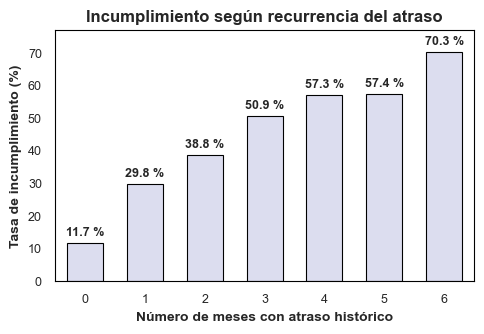

In [58]:
plt.figure(figsize=(5, 3.5))

ax = sns.barplot(data=resumen_recurrencia, x="meses_con_atraso", y="Tasa_incumplimiento", color="#D9DAF2", edgecolor="black", linewidth=0.8, width=0.6)
for barra, porcentaje in zip(ax.patches, resumen_recurrencia["Tasa_incumplimiento"]):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + 1.2,
    f"{porcentaje:.1f} %", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.title("Incumplimiento según recurrencia del atraso", fontsize=12, fontweight="bold")
plt.xlabel("Número de meses con atraso histórico", fontsize=10, fontweight="bold")
plt.ylabel("Tasa de incumplimiento (%)", fontsize=10, fontweight="bold")

plt.ylim(0, 77)
ax.grid(False)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [59]:
# ------------- SEVERIDAD DE ATRASO VS INCUMPLIMIENTO ------------- #

# Máximo nivel de atraso registrado en los seis periodos analizados
datos["maximo_atraso_historico"] = datos[variables_pago].clip(lower=0).max(axis=1)

resumen_severidad = datos.groupby("maximo_atraso_historico")["default payment next month"].agg(
    Clientes="count",
    Incumplimientos="sum",
    Tasa_incumplimiento="mean"
).reset_index()

resumen_severidad["Porcentaje_muestra"] = resumen_severidad["Clientes"] / len(datos) * 100
resumen_severidad["Tasa_incumplimiento"] = resumen_severidad["Tasa_incumplimiento"] * 100
print(resumen_severidad.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

 maximo_atraso_historico  Clientes  Incumplimientos  Tasa_incumplimiento  Porcentaje_muestra
                       0     19931             2334                11.71               66.44
                       1      1689              422                24.99                5.63
                       2      7187             3130                43.55               23.96
                       3       789              491                62.23                2.63
                       4       218              140                64.22                0.73
                       5        69               35                50.72                0.23
                       6        25               14                56.00                0.08
                       7        67               56                83.58                0.22
                       8        25               14                56.00                0.08


### **Saldos facturados**

In [60]:
# ----------------------- SALDOS FACTURADOS ----------------------- #

variables_bill = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
resumen_bill = datos[variables_bill].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]).T
print("\n Resumen de saldos:")
print(resumen_bill.to_string(index=False))


 Resumen de saldos:
    count      mean       std         min      25%       50%       75%        95%        99%          max
30,000.00 51,223.33 73,635.86 -165,580.00 3,558.75 22,381.50 67,091.00 201,203.05 350,110.68   964,511.00
30,000.00 49,179.08 71,173.77  -69,777.00 2,984.75 21,200.00 64,006.25 194,792.20 337,495.28   983,931.00
30,000.00 47,013.15 69,349.39 -157,264.00 2,666.25 20,088.50 60,164.75 187,821.05 325,030.39 1,664,089.00
30,000.00 43,262.95 64,332.86 -170,000.00 2,326.75 19,052.00 54,506.00 174,333.35 304,997.27   891,586.00
30,000.00 40,311.40 60,797.16  -81,334.00 1,763.00 18,104.50 50,190.50 165,794.30 285,868.33   927,171.00
30,000.00 38,871.76 59,554.11 -339,603.00 1,256.00 17,071.00 49,198.25 161,912.00 279,505.06   961,664.00


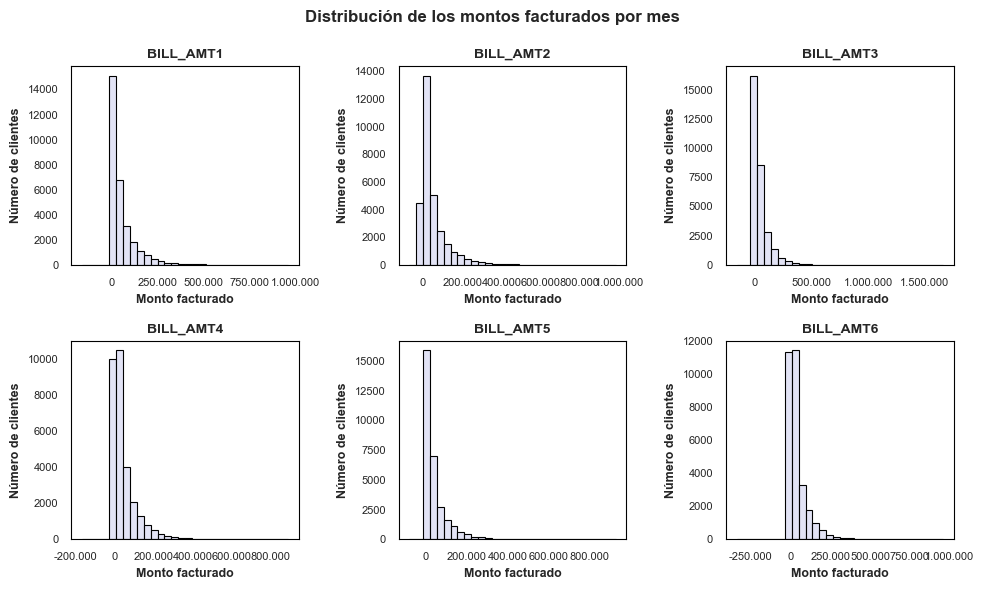

In [61]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten()

for i, variable in enumerate(variables_bill):
    sns.histplot(data=datos, x=variable, bins=30, color="#D9DAF2", edgecolor="black", linewidth=0.8, ax=axes[i])
    axes[i].set_title(variable, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Monto facturado", fontsize=9, fontweight="bold")
    axes[i].set_ylabel("Número de clientes", fontsize=9, fontweight="bold")
    axes[i].tick_params(axis="both", labelsize=8)
    axes[i].xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
    axes[i].grid(False)

    for borde in axes[i].spines.values():
        borde.set_visible(True)
        borde.set_color("black")
        borde.set_linewidth(0.8)

fig.suptitle("Distribución de los montos facturados por mes", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [62]:
medianas_bill_target = datos.groupby("default payment next month")[variables_bill].median().T
medianas_bill_target.columns = ["No incumplimiento", "Incumplimiento"]
print("Resumen de medianas por saldos:")
print(medianas_bill_target)

medias_bill_target = datos.groupby("default payment next month")[variables_bill].mean().T
medias_bill_target.columns = ["No incumplimiento", "Incumplimiento"]
print("\n Resumen de medias por saldos:")
print(medias_bill_target.round(2))

Resumen de medianas por saldos:
           No incumplimiento  Incumplimiento
BILL_AMT1          23,119.50       20,185.00
BILL_AMT2          21,660.50       20,300.50
BILL_AMT3          20,202.50       19,834.50
BILL_AMT4          19,000.00       19,119.50
BILL_AMT5          17,998.00       18,478.50
BILL_AMT6          16,679.00       18,028.50

 Resumen de medias por saldos:
           No incumplimiento  Incumplimiento
BILL_AMT1          51,994.23       48,509.16
BILL_AMT2          49,717.44       47,283.62
BILL_AMT3          47,533.37       45,181.60
BILL_AMT4          43,611.17       42,036.95
BILL_AMT5          40,530.45       39,540.19
BILL_AMT6          39,042.27       38,271.44


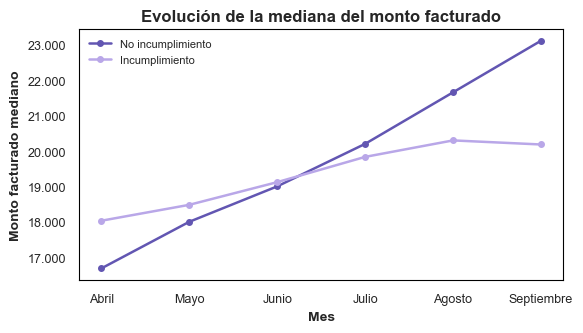

In [63]:
evolucion_bill = medianas_bill_target.loc[["BILL_AMT6", "BILL_AMT5", "BILL_AMT4", "BILL_AMT3", "BILL_AMT2", "BILL_AMT1"]].copy()
evolucion_bill["Mes"] = ["Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre"]

plt.figure(figsize=(6, 3.5))

ax = plt.gca()
ax.plot(evolucion_bill["Mes"], evolucion_bill["No incumplimiento"], marker="o", markersize=4, linewidth=1.8, color="#6256B2", label="No incumplimiento")
ax.plot(evolucion_bill["Mes"], evolucion_bill["Incumplimiento"], marker="o", markersize=4, linewidth=1.8, color="#B9A7E8", label="Incumplimiento")

plt.title("Evolución de la mediana del monto facturado", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Mes", fontsize=10, fontweight="bold")
plt.ylabel("Monto facturado mediano", fontsize=10, fontweight="bold")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
ax.grid(False)
for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.legend(frameon=False, fontsize=8)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [64]:
# ---------------- UTILIZACIÓN DEL LIMITE PROMEDIO ---------------- #

variables_utilizacion = []

for i in range(1, 7):
    nueva_variable = f"UTILIZACION_{i}"
    datos[nueva_variable] = datos[f"BILL_AMT{i}"] / datos["LIMIT_BAL"]
    variables_utilizacion.append(nueva_variable)

resumen_utilizacion = datos.groupby("default payment next month")[variables_utilizacion].median().T.reset_index()
resumen_utilizacion.columns = ["Periodo", "No_incumplimiento", "Incumplimiento"]
resumen_utilizacion["Periodo"] = ["Mes 1", "Mes 2", "Mes 3", "Mes 4", "Mes 5", "Mes 6"]
print(resumen_utilizacion.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Periodo  No_incumplimiento  Incumplimiento
  Mes 1             0.2675          0.4929
  Mes 2             0.2486          0.4941
  Mes 3             0.2256          0.4627
  Mes 4             0.1975          0.4068
  Mes 5             0.1784          0.3729
  Mes 6             0.1543          0.3521


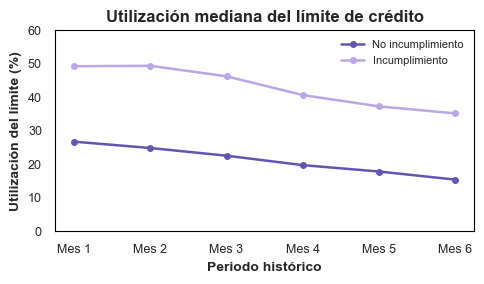

In [65]:
grafico_utilizacion = resumen_utilizacion.copy()
grafico_utilizacion["No_incumplimiento"] = grafico_utilizacion["No_incumplimiento"] * 100
grafico_utilizacion["Incumplimiento"] = grafico_utilizacion["Incumplimiento"] * 100

plt.figure(figsize=(5, 3))

plt.plot(grafico_utilizacion["Periodo"], grafico_utilizacion["No_incumplimiento"], marker="o", markersize=4, linewidth=1.8, color="#6256B2", label="No incumplimiento")
plt.plot(grafico_utilizacion["Periodo"], grafico_utilizacion["Incumplimiento"], marker="o", markersize=4, linewidth=1.8, color="#B9A7E8", label="Incumplimiento")
plt.title("Utilización mediana del límite de crédito", fontsize=12, fontweight="bold")
plt.xlabel("Periodo histórico", fontsize=10, fontweight="bold")
plt.ylabel("Utilización del límite (%)", fontsize=10, fontweight="bold")

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.ylim(0, 60)
plt.legend(frameon=False, fontsize=8)

ax = plt.gca()
ax.grid(False)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.tight_layout()
plt.show()

In [66]:
print(datos[variables_utilizacion].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]).T.to_string(float_format=lambda x: f"{x:.3f}"))

                  count  mean   std    min     1%   25%   50%   75%   95%   99%    max
UTILIZACION_1 30000.000 0.424 0.411 -0.620 -0.000 0.022 0.314 0.830 1.013 1.232  6.455
UTILIZACION_2 30000.000 0.411 0.405 -1.396 -0.001 0.018 0.296 0.806 1.010 1.164  6.380
UTILIZACION_3 30000.000 0.392 0.396 -1.025 -0.001 0.016 0.273 0.755 1.002 1.117 10.689
UTILIZACION_4 30000.000 0.360 0.369 -1.375 -0.001 0.014 0.242 0.668 0.986 1.055  5.147
UTILIZACION_5 30000.000 0.333 0.351 -0.877 -0.002 0.011 0.212 0.602 0.974 1.031  4.936
UTILIZACION_6 30000.000 0.319 0.345 -1.510 -0.002 0.008 0.185 0.582 0.974 1.022  3.886


In [67]:
# Porcentaje de clientes con utilización superior al 100 % o negativa
for variable in variables_utilizacion:
    porcentaje_sobre_limite = (datos[variable] > 1).mean() * 100
    porcentaje_negativo = (datos[variable] < 0).mean() * 100
    print(f"{variable}: >100% = {porcentaje_sobre_limite:.2f}% | Negativa = {porcentaje_negativo:.2f}%")

UTILIZACION_1: >100% = 7.05% | Negativa = 1.97%
UTILIZACION_2: >100% = 6.47% | Negativa = 2.23%
UTILIZACION_3: >100% = 5.28% | Negativa = 2.18%
UTILIZACION_4: >100% = 3.39% | Negativa = 2.25%
UTILIZACION_5: >100% = 2.73% | Negativa = 2.18%
UTILIZACION_6: >100% = 2.66% | Negativa = 2.29%


In [68]:
datos["utilizacion_mediana_historica"] = datos[variables_utilizacion].median(axis=1)
resumen_utilizacion_historica = datos.groupby("default payment next month")["utilizacion_mediana_historica"].agg(["count", "mean", "median", "std"]).reset_index()
print(resumen_utilizacion_historica.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

 default payment next month  count   mean  median    std
                          0  23364 0.3481  0.2165 0.3592
                          1   6636 0.4515  0.4555 0.3840


In [69]:
utilizacion_no_incumplimiento = datos.loc[datos["default payment next month"] == 0, "utilizacion_mediana_historica"]
utilizacion_incumplimiento = datos.loc[datos["default payment next month"] == 1, "utilizacion_mediana_historica"]

estadistico_u, p_valor = mannwhitneyu(
    utilizacion_no_incumplimiento,
    utilizacion_incumplimiento,
    alternative="two-sided")

n_no_incumplimiento = len(utilizacion_no_incumplimiento)
n_incumplimiento = len(utilizacion_incumplimiento)

correlacion_biserial = 1 - (2 * estadistico_u) / (n_no_incumplimiento * n_incumplimiento)

print(f"U de Mann-Whitney: {estadistico_u:.0f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Correlación biserial por rangos: {correlacion_biserial:.4f}")

U de Mann-Whitney: 67490182
p-valor: 0.000000
Correlación biserial por rangos: 0.1294


### **Pagos realizados**

In [70]:
# ------------------------ PAGOS REALIZADOS ----------------------- #

variables_pay_amt = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
resumen_pay_amt = datos[variables_pay_amt].describe(percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]).T
print(resumen_pay_amt.to_string())

             count     mean       std  min      25%      50%      75%       95%       99%          max
PAY_AMT1 30,000.00 5,663.58 16,563.28 0.00 1,000.00 2,100.00 5,006.00 18,428.20 66,522.18   873,552.00
PAY_AMT2 30,000.00 5,921.16 23,040.87 0.00   833.00 2,009.00 5,000.00 19,004.35 76,651.02 1,684,259.00
PAY_AMT3 30,000.00 5,225.68 17,606.96 0.00   390.00 1,800.00 4,505.00 17,589.40 70,000.00   896,040.00
PAY_AMT4 30,000.00 4,826.08 15,666.16 0.00   296.00 1,500.00 4,013.25 16,014.95 67,054.44   621,000.00
PAY_AMT5 30,000.00 4,799.39 15,278.31 0.00   252.50 1,500.00 4,031.50 16,000.00 65,607.56   426,529.00
PAY_AMT6 30,000.00 5,215.50 17,777.47 0.00   117.75 1,500.00 4,000.00 17,343.80 82,619.05   528,666.00


In [71]:
# Número de pagos iguales a cero en cada periodo
ceros_pay_amt = (datos[variables_pay_amt] == 0).sum()
print("Pagos iguales a cero por variable:")
print(ceros_pay_amt)

Pagos iguales a cero por variable:
PAY_AMT1    5249
PAY_AMT2    5396
PAY_AMT3    5968
PAY_AMT4    6408
PAY_AMT5    6703
PAY_AMT6    7173
dtype: int64


In [72]:
medianas_pay_amt = datos[variables_pay_amt].median()
evolucion_pay_amt = medianas_pay_amt.loc[["PAY_AMT6", "PAY_AMT5", "PAY_AMT4", "PAY_AMT3", "PAY_AMT2", "PAY_AMT1"]]
evolucion_pay_amt.index = ["Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre"]
print("\n Evolución de la mediana de los montos pagados:")
print(evolucion_pay_amt)

medianas_pay_target = datos.groupby("default payment next month")[variables_pay_amt].median().T
medianas_pay_target.index = ["Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre"]
medianas_pay_target.columns = ["No incumplimiento", "Incumplimiento"]
print("\n Mediana de los montos pagados por tipo de incumplimiento:")
print(medianas_pay_target)

medias_pay_target = datos.groupby("default payment next month")[variables_pay_amt].mean().T
medias_pay_target.index = ["Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre"]
medias_pay_target.columns = ["No incumplimiento", "Incumplimiento"]
print("\n Media de los montos pagados por tipo de incumplimiento:")
print(medias_pay_target.round(2))


 Evolución de la mediana de los montos pagados:
Abril        1,500.00
Mayo         1,500.00
Junio        1,500.00
Julio        1,800.00
Agosto       2,009.00
Septiembre   2,100.00
dtype: float64

 Mediana de los montos pagados por tipo de incumplimiento:
            No incumplimiento  Incumplimiento
Abril                2,459.50        1,636.00
Mayo                 2,247.50        1,533.50
Junio                2,000.00        1,222.00
Julio                1,734.00        1,000.00
Agosto               1,765.00        1,000.00
Septiembre           1,706.00        1,000.00

 Media de los montos pagados por tipo de incumplimiento:
            No incumplimiento  Incumplimiento
Abril                6,307.34        3,397.04
Mayo                 6,640.47        3,388.65
Junio                5,753.50        3,367.35
Julio                5,300.53        3,155.63
Agosto               5,248.22        3,219.14
Septiembre           5,719.37        3,441.48


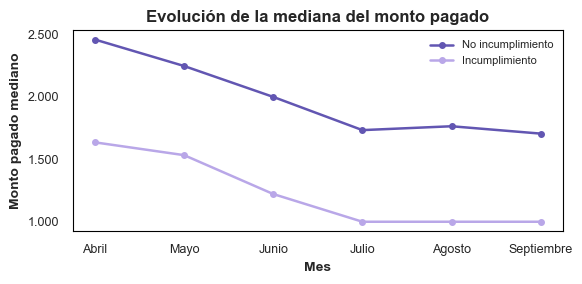

In [73]:
evolucion_pay_target = medianas_pay_target.loc[["Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre"]].copy()
evolucion_pay_target["Mes"] = ["Abril", "Mayo", "Junio", "Julio", "Agosto", "Septiembre"]

plt.figure(figsize=(6, 3))

ax = plt.gca()
ax.plot(evolucion_pay_target["Mes"], evolucion_pay_target["No incumplimiento"], marker="o", markersize=4, linewidth=1.8, color="#6256B2", label="No incumplimiento")
ax.plot(evolucion_pay_target["Mes"], evolucion_pay_target["Incumplimiento"], marker="o", markersize=4, linewidth=1.8, color="#B9A7E8", label="Incumplimiento")

plt.title("Evolución de la mediana del monto pagado", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("Mes", fontsize=10, fontweight="bold")
plt.ylabel("Monto pagado mediano", fontsize=10, fontweight="bold")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:,.0f}".replace(",", ".")))
ax.grid(False)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [74]:
# --------------------- PERIODOS SIN PAGO --------------------- #

# Número de periodos en los que el cliente no realizó ningún pago
datos["meses_pago_cero"] = (datos[variables_pay_amt] == 0).sum(axis=1)

resumen_pago_cero = datos.groupby("meses_pago_cero")["default payment next month"].agg(
    Clientes="count",
    Incumplimientos="sum",
    Tasa_incumplimiento="mean"
).reset_index()

resumen_pago_cero["Porcentaje_muestra"] = resumen_pago_cero["Clientes"] / len(datos) * 100
resumen_pago_cero["Tasa_incumplimiento"] = resumen_pago_cero["Tasa_incumplimiento"] * 100
print(resumen_pago_cero.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

 meses_pago_cero  Clientes  Incumplimientos  Tasa_incumplimiento  Porcentaje_muestra
               0     15458             2151                13.92               51.53
               1      5473             1586                28.98               18.24
               2      3387             1141                33.69               11.29
               3      1944              608                31.28                6.48
               4      1304              328                25.15                4.35
               5      1002              278                27.74                3.34
               6      1432              544                37.99                4.77


In [75]:
# --------------------- PAGO TOTAL HISTÓRICO --------------------- #

# Suma de los pagos realizados durante los seis periodos
datos["pago_total_historico"] = datos[variables_pay_amt].sum(axis=1)

resumen_pago_total = datos.groupby("default payment next month")["pago_total_historico"].agg(
    Clientes="count",
    Media="mean",
    Mediana="median",
    Desviacion="std"
).reset_index()
print(resumen_pago_total.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

 default payment next month  Clientes     Media   Mediana  Desviacion
                          0     23364 34,969.42 16,524.00   65,682.26
                          1      6636 19,969.29  9,674.50   36,915.63


In [76]:
pago_no_incumplimiento = datos.loc[datos["default payment next month"] == 0, "pago_total_historico"]
pago_incumplimiento = datos.loc[datos["default payment next month"] == 1, "pago_total_historico"]

estadistico_u, p_valor = mannwhitneyu(
    pago_no_incumplimiento,
    pago_incumplimiento,
    alternative="two-sided"
)

n_no_incumplimiento = len(pago_no_incumplimiento)
n_incumplimiento = len(pago_incumplimiento)
correlacion_biserial = abs(1 - (2 * estadistico_u) / (n_no_incumplimiento * n_incumplimiento))

print(f"U de Mann-Whitney: {estadistico_u:.0f}")
print(f"p-valor: {p_valor:.6f}")
print(f"Correlación biserial por rangos: {correlacion_biserial:.4f}")

U de Mann-Whitney: 96299484
p-valor: 0.000000
Correlación biserial por rangos: 0.2422


### **Correlación**

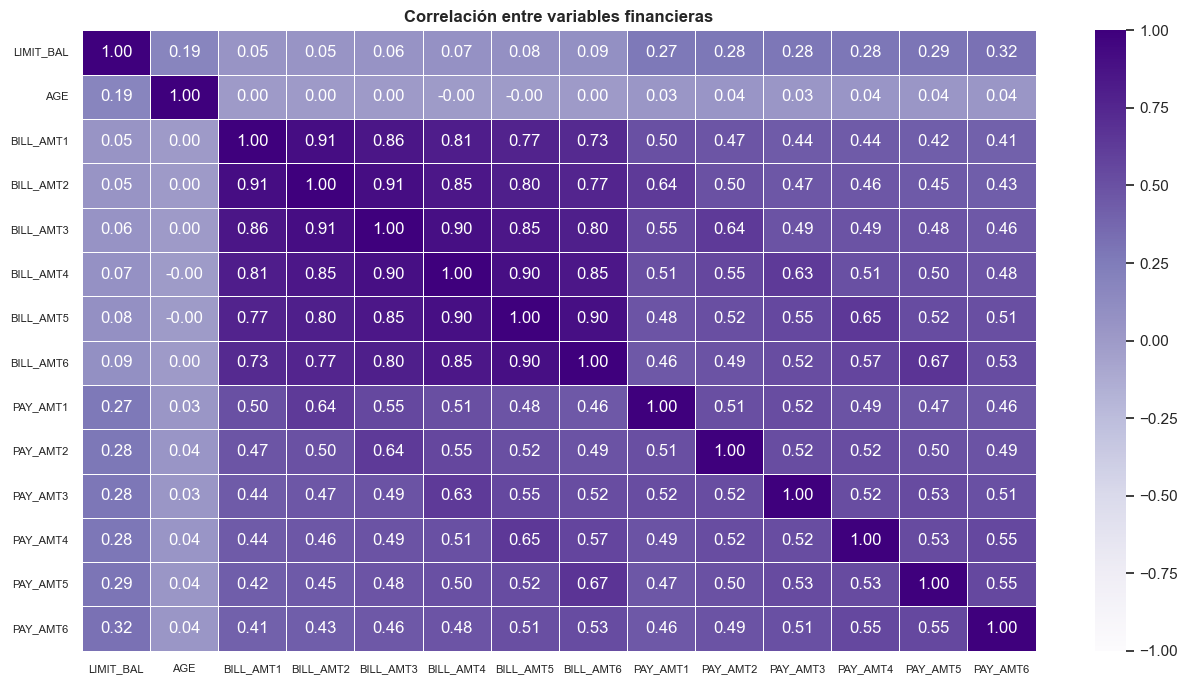

In [77]:
# -------------------------- CORRELACIONES -------------------------- #

plt.figure(figsize=(13, 7))

# Variables financieras incluidas en el análisis de correlación
variables_correlacion = ["LIMIT_BAL", "AGE",
                         "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
                         "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

correlaciones = datos[variables_correlacion].corr(method="spearman")
ax = sns.heatmap(correlaciones, cmap="Purples", annot=True, fmt=".2f", linewidths=0.5, linecolor="white", vmin=-1, vmax=1)

plt.title("Correlación entre variables financieras", fontsize=12, fontweight="bold", loc="center")
plt.xlabel("")
plt.ylabel("")
plt.xticks(fontsize=8, rotation=0)
plt.yticks(fontsize=8, rotation=0)

plt.tight_layout()
plt.show()

In [78]:
pares_correlacion = correlaciones.where(np.triu(np.ones(correlaciones.shape), k=1).astype(bool)).stack().reset_index()
pares_correlacion.columns = ["Variable_1", "Variable_2", "Correlacion"]
pares_correlacion["Correlacion_absoluta"] = pares_correlacion["Correlacion"].abs()
correlaciones_altas = pares_correlacion[pares_correlacion["Correlacion_absoluta"] >= 0.70].sort_values("Correlacion_absoluta", ascending=False)

print(correlaciones_altas.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Variable_1 Variable_2  Correlacion  Correlacion_absoluta
 BILL_AMT1  BILL_AMT2       0.9111                0.9111
 BILL_AMT2  BILL_AMT3       0.9077                0.9077
 BILL_AMT3  BILL_AMT4       0.9036                0.9036
 BILL_AMT4  BILL_AMT5       0.9028                0.9028
 BILL_AMT5  BILL_AMT6       0.9021                0.9021
 BILL_AMT1  BILL_AMT3       0.8577                0.8577
 BILL_AMT3  BILL_AMT5       0.8485                0.8485
 BILL_AMT2  BILL_AMT4       0.8484                0.8484
 BILL_AMT4  BILL_AMT6       0.8480                0.8480
 BILL_AMT1  BILL_AMT4       0.8073                0.8073
 BILL_AMT3  BILL_AMT6       0.8042                0.8042
 BILL_AMT2  BILL_AMT5       0.8029                0.8029
 BILL_AMT1  BILL_AMT5       0.7690                0.7690
 BILL_AMT2  BILL_AMT6       0.7652                0.7652
 BILL_AMT1  BILL_AMT6       0.7343                0.7343


### **Identificación de posibles outliers**

In [79]:
variables_financieras = [
    "LIMIT_BAL",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"
]

# Revisión de valores mínimos, máximos y percentiles extremos
resumen_extremos = datos[variables_financieras].quantile([0, 0.01, 0.50, 0.99, 1]).T.reset_index()
resumen_extremos.columns = ["Variable", "Minimo", "P1", "Mediana", "P99", "Maximo"]

print(resumen_extremos.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

 Variable      Minimo        P1    Mediana        P99       Maximo
LIMIT_BAL   10,000.00 10,000.00 140,000.00 500,000.00 1,000,000.00
BILL_AMT1 -165,580.00    -81.00  22,381.50 350,110.68   964,511.00
BILL_AMT2  -69,777.00   -200.00  21,200.00 337,495.28   983,931.00
BILL_AMT3 -157,264.00   -200.00  20,088.50 325,030.39 1,664,089.00
BILL_AMT4 -170,000.00   -212.02  19,052.00 304,997.27   891,586.00
BILL_AMT5  -81,334.00   -232.01  18,104.50 285,868.33   927,171.00
BILL_AMT6 -339,603.00   -331.03  17,071.00 279,505.06   961,664.00
 PAY_AMT1        0.00      0.00   2,100.00  66,522.18   873,552.00
 PAY_AMT2        0.00      0.00   2,009.00  76,651.02 1,684,259.00
 PAY_AMT3        0.00      0.00   1,800.00  70,000.00   896,040.00
 PAY_AMT4        0.00      0.00   1,500.00  67,054.44   621,000.00
 PAY_AMT5        0.00      0.00   1,500.00  65,607.56   426,529.00
 PAY_AMT6        0.00      0.00   1,500.00  82,619.05   528,666.00


In [80]:
# Revisión de valores negativos y valores iguales a cero
resumen_calidad_financiera = pd.DataFrame({
    "Variable": variables_financieras,
    "Valores_negativos": [(datos[variable] < 0).sum() for variable in variables_financieras],
    "Valores_cero": [(datos[variable] == 0).sum() for variable in variables_financieras]
})

resumen_calidad_financiera["Negativos_%"] = resumen_calidad_financiera["Valores_negativos"] / len(datos) * 100
resumen_calidad_financiera["Ceros_%"] = resumen_calidad_financiera["Valores_cero"] / len(datos) * 100

print(resumen_calidad_financiera.to_string(index=False, float_format=lambda x: f"{x:.2f}"))

 Variable  Valores_negativos  Valores_cero  Negativos_%  Ceros_%
LIMIT_BAL                  0             0         0.00     0.00
BILL_AMT1                590          2008         1.97     6.69
BILL_AMT2                669          2506         2.23     8.35
BILL_AMT3                655          2870         2.18     9.57
BILL_AMT4                675          3195         2.25    10.65
BILL_AMT5                655          3506         2.18    11.69
BILL_AMT6                688          4020         2.29    13.40
 PAY_AMT1                  0          5249         0.00    17.50
 PAY_AMT2                  0          5396         0.00    17.99
 PAY_AMT3                  0          5968         0.00    19.89
 PAY_AMT4                  0          6408         0.00    21.36
 PAY_AMT5                  0          6703         0.00    22.34
 PAY_AMT6                  0          7173         0.00    23.91


## **PREPARACIÓN DE LOS DATOS**

In [81]:
target = "default payment next month"

# Variables demográficas utilizadas para el análisis de equidad
variables_demograficas = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
# Variables originales utilizadas como predictores
variables_originales = ["LIMIT_BAL", "SEX", "EDUCATION", "MARRIAGE", "AGE",
    "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

# Separación de predictores y variable objetivo
X = datos[variables_originales].copy()
y = datos[target].copy()

print("Predictores originales:", X.shape[1])
print("Observaciones:", X.shape[0])

Predictores originales: 23
Observaciones: 30000


In [82]:
# División estratificada: 80% entrenamiento y 20% prueba
X_train_original, X_test_original, y_train, y_test, demograficos_train, demograficos_test = train_test_split(
    X, y, datos[variables_demograficas], test_size=0.20, random_state=123, stratify=y)

print("Train:", X_train_original.shape)
print("Test:", X_test_original.shape)

print("\nDistribución target - Train")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribución target - Test")
print(y_test.value_counts(normalize=True).sort_index())

Train: (24000, 23)
Test: (6000, 23)

Distribución target - Train
default payment next month
0   0.78
1   0.22
Name: proportion, dtype: float64

Distribución target - Test
default payment next month
0   0.78
1   0.22
Name: proportion, dtype: float64


In [83]:
# Escenario con variables demográficas
X_train_con = X_train_original.copy()
X_test_con = X_test_original.copy()

# Escenario sin variables demográficas
X_train_sin = X_train_original.drop(columns=variables_demograficas).copy()
X_test_sin = X_test_original.drop(columns=variables_demograficas).copy()

In [84]:
# Codificación de variables categóricas para el escenario con demográficas
variables_categoricas = ["SEX", "EDUCATION", "MARRIAGE"]

X_train_con = pd.get_dummies(X_train_con, columns=variables_categoricas, drop_first=True, dtype=int)
X_test_con = pd.get_dummies(X_test_con, columns=variables_categoricas, drop_first=True, dtype=int)

X_test_con = X_test_con.reindex(columns=X_train_con.columns, fill_value=0)

print("Con demografía:")
print("Train:", X_train_con.shape)
print("Test:", X_test_con.shape)

print("\nSin demografía:")
print("Train:", X_train_sin.shape)
print("Test:", X_test_sin.shape)

Con demografía:
Train: (24000, 28)
Test: (6000, 28)

Sin demografía:
Train: (24000, 19)
Test: (6000, 19)


## **MODELADO Y OPTIMIZACIÓN**

In [85]:
variables_continuas_con = ["LIMIT_BAL", "AGE",
                           "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
                           "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

variables_continuas_sin = ["LIMIT_BAL",
                           "BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6",
                           "PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

## **REGRESION LOGISTICA CON DEMOGRAFICAS**

In [87]:
# Escalado de las variables continuas
preprocesador_con = ColumnTransformer([("escalado", StandardScaler(), variables_continuas_con)], remainder="passthrough")

# Pipeline de preprocesamiento y modelo
modelo_regresion_con = Pipeline([
    ("preprocesamiento", preprocesador_con),
    ("modelo", LogisticRegression(max_iter=5000, random_state=123))])

# Validación cruzada estratificada
validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Espacio de hiperparámetros
espacio_regresion_con = [
    {"modelo__solver": ["liblinear"], 
     "modelo__penalty": ["l1", "l2"], 
     "modelo__C": np.logspace(-4, 3, 15)},
    {"modelo__solver": ["saga"], 
     "modelo__penalty": ["elasticnet"], 
     "modelo__C": np.logspace(-4, 3, 15),
     "modelo__l1_ratio": [0.25, 0.50, 0.75]}
]

# Optimización mediante GridSearchCV
busqueda_regresion_con = GridSearchCV(modelo_regresion_con, espacio_regresion_con, scoring=metricas, refit="roc_auc", cv=validacion_cruzada, n_jobs=-1)

busqueda_regresion_con.fit(X_train_con, y_train)

# Mejor modelo
mejor_regresion_con_demografia = busqueda_regresion_con.best_estimator_
indice_mejor_modelo = busqueda_regresion_con.best_index_

print("Mejores parámetros:", busqueda_regresion_con.best_params_)
print("\nMétricas de validación cruzada:")

for metrica in metricas:
    print(f"{metrica}: {busqueda_regresion_con.cv_results_[f'mean_test_{metrica}'][indice_mejor_modelo]:.4f}")

Mejores parámetros: {'modelo__C': 316.22776601683796, 'modelo__l1_ratio': 0.25, 'modelo__penalty': 'elasticnet', 'modelo__solver': 'saga'}

Métricas de validación cruzada:
roc_auc: 0.7238
pr_auc: 0.5022
recall: 0.2400
accuracy: 0.8101
precision: 0.7095
f1: 0.3586
balanced_accuracy: 0.6060


## **REGRESION LOGISTICA SIN DEMOGRAFICAS**

In [ ]:
# Escalado de las variables continuas
preprocesador_sin = ColumnTransformer([("escalado", StandardScaler(), variables_continuas_sin)], remainder="passthrough")

# Pipeline de preprocesamiento y modelo
modelo_regresion_sin = Pipeline([
    ("preprocesamiento", preprocesador_sin),
    ("modelo", LogisticRegression(max_iter=5000, random_state=123))])

# Validación cruzada estratificada
validacion_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Espacio de hiperparámetros
espacio_regresion_sin = [
    {"modelo__solver": ["liblinear"], 
     "modelo__penalty": ["l1", "l2"], 
     "modelo__C": np.logspace(-4, 3, 15)},
    {"modelo__solver": ["saga"], 
     "modelo__penalty": ["elasticnet"], 
     "modelo__C": np.logspace(-4, 3, 15),
     "modelo__l1_ratio": [0.25, 0.50, 0.75]}
]

# Optimización mediante GridSearchCV
busqueda_regresion_sin = GridSearchCV(modelo_regresion_sin, espacio_regresion_sin, scoring=metricas, refit="roc_auc", cv=validacion_cruzada, n_jobs=-1)

busqueda_regresion_sin.fit(X_train_sin, y_train)

# Mejor modelo
mejor_regresion_sin_demografia = busqueda_regresion_sin.best_estimator_
indice_mejor_modelo = busqueda_regresion_sin.best_index_

print("Mejores parámetros:", busqueda_regresion_sin.best_params_)
print("\nMétricas de validación cruzada:")

for metrica in metricas: 
    print(f"{metrica}: {busqueda_regresion_sin.cv_results_[f'mean_test_{metrica}'][indice_mejor_modelo]:.4f}")

Mejores parámetros: {'modelo__C': 1000.0, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}

Métricas de validación cruzada:
roc_auc: 0.7214
pr_auc: 0.5018
recall: 0.2268
accuracy: 0.8083
precision: 0.7086
f1: 0.3435
balanced_accuracy: 0.6002


## **RANDOM FOREST CON DEMOGRAFICAS**

In [ ]:
# Modelo base
modelo_random_forest_con = RandomForestClassifier(random_state=123, n_jobs=1)

# Validación cruzada estratificada
validacion_cruzada_rf_con = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Espacio de hiperparámetros
espacio_random_forest_con = {
    "n_estimators": randint(300, 1001),
    "max_depth": [None, 10, 15, 20, 25, 30, 35],
    "min_samples_split": randint(2, 25),
    "min_samples_leaf": randint(1, 40),
    "max_features": ["sqrt", "log2", 0.5],
    "criterion": ["gini", "entropy", "log_loss"],
    "bootstrap": [True, False]
}

# Optimización mediante RandomizedSearchCV
busqueda_random_forest_con = RandomizedSearchCV(modelo_random_forest_con, espacio_random_forest_con, n_iter=50, scoring=metricas, refit="roc_auc",
    cv=validacion_cruzada_rf_con, random_state=123, n_jobs=-1)

busqueda_random_forest_con.fit(X_train_con, y_train)

# Mejor modelo
mejor_random_forest_con_demografia = busqueda_random_forest_con.best_estimator_
indice_mejor_rf_con = busqueda_random_forest_con.best_index_

print("Mejores parámetros:", busqueda_random_forest_con.best_params_)
print("\nMétricas de validación cruzada:")

for metrica in metricas:
    print(f"{metrica}: {busqueda_random_forest_con.cv_results_[f'mean_test_{metrica}'][indice_mejor_rf_con]:.4f}")

Mejores parámetros: {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 33, 'min_samples_split': 5, 'n_estimators': 879}

Métricas de validación cruzada:
roc_auc: 0.7840
pr_auc: 0.5589
recall: 0.3530
accuracy: 0.8190
precision: 0.6737
f1: 0.4631
balanced_accuracy: 0.6522


## **RANDOM FOREST SIN DEMOGRAFICAS**

In [ ]:
# Modelo base
modelo_random_forest_sin = RandomForestClassifier(random_state=123, n_jobs=1)

# Validación cruzada estratificada
validacion_cruzada_rf_sin = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Espacio de hiperparámetros
espacio_random_forest_sin = {
    "n_estimators": randint(300, 1001),
    "max_depth": [None, 10, 15, 20, 25, 30, 35],
    "min_samples_split": randint(2, 25),
    "min_samples_leaf": randint(1, 40),
    "max_features": ["sqrt", "log2", 0.5],
    "criterion": ["gini", "entropy", "log_loss"],
    "bootstrap": [True, False]
}

# Optimización mediante RandomizedSearchCV
busqueda_random_forest_sin = RandomizedSearchCV(modelo_random_forest_sin, espacio_random_forest_sin, n_iter=50, scoring=metricas, refit="roc_auc",
    cv=validacion_cruzada_rf_sin, random_state=123, n_jobs=-1)

busqueda_random_forest_sin.fit(X_train_sin, y_train)

# Mejor modelo
mejor_random_forest_sin_demografia = busqueda_random_forest_sin.best_estimator_
indice_mejor_rf_sin = busqueda_random_forest_sin.best_index_

print("Mejores parámetros:", busqueda_random_forest_sin.best_params_)
print("\nMétricas de validación cruzada:")

for metrica in metricas:
    print(f"{metrica}: {busqueda_random_forest_sin.cv_results_[f'mean_test_{metrica}'][indice_mejor_rf_sin]:.4f}")

## **XGBOOST CON DEMOGRAFICAS**

In [ ]:
# Validación cruzada estratificada
validacion_cruzada_xgb_con = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Función objetivo para la optimización con Optuna
def objetivo_xgb_con(trial):
    parametros = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0001, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True)
    }

    modelo = XGBClassifier(**parametros, objective="binary:logistic", eval_metric="logloss", tree_method="hist", verbosity=0, random_state=123, n_jobs=1)

    roc_auc = cross_val_score(modelo, X_train_con, y_train, scoring="roc_auc", cv=validacion_cruzada_xgb_con, n_jobs=-1).mean()

    return roc_auc

# Optimización de hiperparámetros
optuna.logging.set_verbosity(optuna.logging.WARNING)
busqueda_xgb_con = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
busqueda_xgb_con.optimize(objetivo_xgb_con, n_trials=40)

# Mejor modelo
mejor_xgboost_con_demografia = XGBClassifier(**busqueda_xgb_con.best_params, objective="binary:logistic", eval_metric="logloss",
    tree_method="hist", random_state=123, n_jobs=1)

mejor_xgboost_con_demografia.fit(X_train_con, y_train)

# Métricas de validación cruzada del mejor modelo
resultados_xgb_con = cross_validate(mejor_xgboost_con_demografia, X_train_con, y_train, scoring=metricas,
    cv=validacion_cruzada_xgb_con, n_jobs=-1)

print("Mejores parámetros:", busqueda_xgb_con.best_params)
print("\nMétricas de validación cruzada:")

for metrica in metricas:
    print(f"{metrica}: {resultados_xgb_con[f'test_{metrica}'].mean():.4f}")

Mejores parámetros: {'n_estimators': 286, 'max_depth': 8, 'learning_rate': 0.03001824368469924, 'min_child_weight': 4, 'subsample': 0.7420566370881222, 'colsample_bytree': 0.637409466414487, 'gamma': 3.9175746113005676, 'reg_alpha': 0.03339509047883216, 'reg_lambda': 8.398355244320213}

Métricas de validación cruzada:
roc_auc: 0.7848
pr_auc: 0.5615
recall: 0.3584
accuracy: 0.8195
precision: 0.6730
f1: 0.4676
balanced_accuracy: 0.6545


## **XGBOOST SIN DEMOGRAFICAS**

In [ ]:
# Validación cruzada estratificada
validacion_cruzada_xgb_sin = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Función objetivo para la optimización con Optuna
def objetivo_xgb_sin(trial):
    parametros = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0001, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True)
    }

    modelo = XGBClassifier(**parametros, objective="binary:logistic", eval_metric="logloss", tree_method="hist", verbosity=0, random_state=123, n_jobs=1)

    roc_auc = cross_val_score(modelo, X_train_sin, y_train, scoring="roc_auc", cv=validacion_cruzada_xgb_sin, n_jobs=-1).mean()

    return roc_auc

# Optimización de hiperparámetros
busqueda_xgb_sin = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
busqueda_xgb_sin.optimize(objetivo_xgb_sin, n_trials=40)

# Mejor modelo
mejor_xgboost_sin_demografia = XGBClassifier(**busqueda_xgb_sin.best_params, objective="binary:logistic", eval_metric="logloss", tree_method="hist", random_state=123, n_jobs=1)

mejor_xgboost_sin_demografia.fit(X_train_sin, y_train)

# Métricas de validación cruzada del mejor modelo
resultados_xgb_sin = cross_validate(mejor_xgboost_sin_demografia, X_train_sin, y_train, scoring=metricas, cv=validacion_cruzada_xgb_sin, n_jobs=-1)

print("Mejores parámetros:", busqueda_xgb_sin.best_params)
print("\nMétricas de validación cruzada:")

for metrica in metricas:
    print(f"{metrica}: {resultados_xgb_sin[f'test_{metrica}'].mean():.4f}")

Mejores parámetros: {'n_estimators': 943, 'max_depth': 6, 'learning_rate': 0.012453945268956566, 'min_child_weight': 9, 'subsample': 0.7899971908524676, 'colsample_bytree': 0.7611926044199002, 'gamma': 3.851157955436651, 'reg_alpha': 0.008879439706838195, 'reg_lambda': 6.478066356168817}

Métricas de validación cruzada:
roc_auc: 0.7836
pr_auc: 0.5588
recall: 0.3637
accuracy: 0.8205
precision: 0.6755
f1: 0.4727
balanced_accuracy: 0.6570


## **LIGHTGBM CON DEMOGRAFICAS**

In [ ]:
# Validación cruzada estratificada
validacion_cruzada_lgbm_con = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Función objetivo para la optimización con Optuna
def objetivo_lgbm_con(trial):
    parametros = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 100),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 5, 7, 10, 15, 20]),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0001, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True)
    }

    modelo = LGBMClassifier(**parametros, objective="binary", subsample_freq=1, verbosity=-1, random_state=123, n_jobs=1)

    roc_auc = cross_val_score(modelo, X_train_con, y_train, scoring="roc_auc", cv=validacion_cruzada_lgbm_con, n_jobs=-1).mean()

    return roc_auc

# Optimización de hiperparámetros
optuna.logging.set_verbosity(optuna.logging.WARNING)

busqueda_lgbm_con = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
busqueda_lgbm_con.optimize(objetivo_lgbm_con, n_trials=40)

# Mejor modelo
mejor_lightgbm_con_demografia = LGBMClassifier(**busqueda_lgbm_con.best_params, objective="binary", subsample_freq=1, verbosity=-1, random_state=123, n_jobs=1)

mejor_lightgbm_con_demografia.fit(X_train_con, y_train)

# Métricas de validación cruzada
resultados_lgbm_con = cross_validate(mejor_lightgbm_con_demografia, X_train_con, y_train, scoring=metricas, cv=validacion_cruzada_lgbm_con, n_jobs=-1)

print("Mejores parámetros:", busqueda_lgbm_con.best_params)
print("\nMétricas de validación cruzada:")

for metrica in metricas:
    print(f"{metrica}: {resultados_lgbm_con[f'test_{metrica}'].mean():.4f}")

Mejores parámetros: {'n_estimators': 726, 'learning_rate': 0.013504188213933704, 'num_leaves': 51, 'max_depth': 5, 'min_child_samples': 93, 'subsample': 0.6285955314711789, 'colsample_bytree': 0.6429638150406094, 'reg_alpha': 0.43438502426868286, 'reg_lambda': 6.427350565800795}

Métricas de validación cruzada:
roc_auc: 0.7847
pr_auc: 0.5600
recall: 0.3626
accuracy: 0.8188
precision: 0.6663
f1: 0.4695
balanced_accuracy: 0.6555


## **LIGHTGBM SIN DEMOGRAFICAS**

In [ ]:
# Validación cruzada estratificada
validacion_cruzada_lgbm_sin = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

metricas = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "accuracy": "accuracy",
            "precision": "precision", "f1": "f1", "balanced_accuracy": "balanced_accuracy"}

# Función objetivo para la optimización con Optuna
def objetivo_lgbm_sin(trial):
    parametros = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 100),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 5, 7, 10, 15, 20]),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.60, 1.00),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.60, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0001, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True)
    }

    modelo = LGBMClassifier(**parametros, objective="binary", subsample_freq=1, verbosity=-1, random_state=123, n_jobs=1)

    roc_auc = cross_val_score(modelo, X_train_sin, y_train, scoring="roc_auc", cv=validacion_cruzada_lgbm_sin, n_jobs=-1).mean()

    return roc_auc

# Optimización de hiperparámetros
busqueda_lgbm_sin = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
busqueda_lgbm_sin.optimize(objetivo_lgbm_sin, n_trials=40)

# Mejor modelo
mejor_lightgbm_sin_demografia = LGBMClassifier( **busqueda_lgbm_sin.best_params, objective="binary", subsample_freq=1, verbosity=-1, random_state=123, n_jobs=1)

mejor_lightgbm_sin_demografia.fit(X_train_sin, y_train)

# Métricas de validación cruzada
resultados_lgbm_sin = cross_validate(mejor_lightgbm_sin_demografia, X_train_sin, y_train, scoring=metricas, cv=validacion_cruzada_lgbm_sin, n_jobs=-1)

print("Mejores parámetros:", busqueda_lgbm_sin.best_params)
print("\nMétricas de validación cruzada:")

for metrica in metricas:
    print(f"{metrica}: {resultados_lgbm_sin[f'test_{metrica}'].mean():.4f}")

Mejores parámetros: {'n_estimators': 663, 'learning_rate': 0.010557766860140259, 'num_leaves': 99, 'max_depth': 7, 'min_child_samples': 99, 'subsample': 0.6025813496879318, 'colsample_bytree': 0.6015352576935019, 'reg_alpha': 0.5507010382481863, 'reg_lambda': 8.324937072570929}

Métricas de validación cruzada:
roc_auc: 0.7839
pr_auc: 0.5587
recall: 0.3583
accuracy: 0.8187
precision: 0.6687
f1: 0.4664
balanced_accuracy: 0.6539


## **GUARDAR MODELOS ENTRENADOS**

In [ ]:
os.makedirs("modelos_guardados", exist_ok=True)

joblib.dump(mejor_regresion_con_demografia, "modelos_guardados/regresion_logistica_con.pkl")
joblib.dump(mejor_regresion_sin_demografia, "modelos_guardados/regresion_logistica_sin.pkl")

joblib.dump(mejor_random_forest_con_demografia, "modelos_guardados/random_forest_con.pkl")
joblib.dump(mejor_random_forest_sin_demografia, "modelos_guardados/random_forest_sin.pkl")

joblib.dump(mejor_xgboost_con_demografia, "modelos_guardados/xgboost_con.pkl")
joblib.dump(mejor_xgboost_sin_demografia, "modelos_guardados/xgboost_sin.pkl")

joblib.dump(mejor_lightgbm_con_demografia, "modelos_guardados/lightgbm_con.pkl")
joblib.dump(mejor_lightgbm_sin_demografia, "modelos_guardados/lightgbm_sin.pkl")

joblib.dump(X_train_con.columns.tolist(), "modelos_guardados/columnas_con.pkl")
joblib.dump(X_train_sin.columns.tolist(), "modelos_guardados/columnas_sin.pkl")

print("Los 8 modelos definitivos fueron guardados correctamente.")

Los 8 modelos definitivos fueron guardados correctamente.


In [ ]:
mejor_regresion_con_demografia = joblib.load("modelos_guardados/regresion_logistica_con.pkl")
mejor_regresion_sin_demografia = joblib.load("modelos_guardados/regresion_logistica_sin.pkl")

mejor_random_forest_con_demografia = joblib.load("modelos_guardados/random_forest_con.pkl")
mejor_random_forest_sin_demografia = joblib.load("modelos_guardados/random_forest_sin.pkl")

mejor_xgboost_con_demografia = joblib.load("modelos_guardados/xgboost_con.pkl")
mejor_xgboost_sin_demografia = joblib.load("modelos_guardados/xgboost_sin.pkl")

mejor_lightgbm_con_demografia = joblib.load("modelos_guardados/lightgbm_con.pkl")
mejor_lightgbm_sin_demografia = joblib.load("modelos_guardados/lightgbm_sin.pkl")

columnas_con = joblib.load("modelos_guardados/columnas_con.pkl")
columnas_sin = joblib.load("modelos_guardados/columnas_sin.pkl")

print("Los 8 modelos definitivos fueron cargados correctamente.")

Los 8 modelos definitivos fueron cargados correctamente.


## **SELECCION DEL UMBRAL DE CLASIFICACIÓN**

In [ ]:
# Validación cruzada para generar probabilidades fuera de muestra
validacion_threshold = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

modelos_threshold = {
    "Regresión Logística - Con demográficas": (mejor_regresion_con_demografia, X_train_con),
    "Regresión Logística - Sin demográficas": (mejor_regresion_sin_demografia, X_train_sin),
    "Random Forest - Con demográficas": (mejor_random_forest_con_demografia, X_train_con),
    "Random Forest - Sin demográficas": (mejor_random_forest_sin_demografia, X_train_sin),
    "XGBoost - Con demográficas": (mejor_xgboost_con_demografia, X_train_con),
    "XGBoost - Sin demográficas": (mejor_xgboost_sin_demografia, X_train_sin),
    "LightGBM - Con demográficas": (mejor_lightgbm_con_demografia, X_train_con),
    "LightGBM - Sin demográficas": (mejor_lightgbm_sin_demografia, X_train_sin)
}

In [ ]:
# Selección del umbral óptimo mediante el índice de Youden
resultados_threshold = []

for nombre_modelo, (modelo, X_train_modelo) in modelos_threshold.items():
    # Probabilidades OOF obtenidas únicamente sobre entrenamiento
    probabilidades_oof = cross_val_predict(modelo, X_train_modelo, y_train, cv=validacion_threshold, method="predict_proba", n_jobs=-1)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_train, probabilidades_oof)

    indice_youden = tpr - fpr
    indice_mejor_threshold = np.argmax(indice_youden)

    threshold_optimo = thresholds[indice_mejor_threshold]

    resultados_threshold.append({
        "Modelo": nombre_modelo,
        "Threshold": threshold_optimo,
        "Youden_J": indice_youden[indice_mejor_threshold],
        "TPR": tpr[indice_mejor_threshold],
        "FPR": fpr[indice_mejor_threshold]
    })

resultados_threshold = pd.DataFrame(resultados_threshold)

print(resultados_threshold.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  Threshold  Youden_J    TPR    FPR
Regresión Logística - Con demográficas     0.2588    0.3759 0.5381 0.1623
Regresión Logística - Sin demográficas     0.2458    0.3878 0.5517 0.1639
      Random Forest - Con demográficas     0.2364    0.4346 0.6282 0.1936
      Random Forest - Sin demográficas     0.2211    0.4366 0.6523 0.2157
            XGBoost - Con demográficas     0.2299    0.4322 0.6297 0.1975
            XGBoost - Sin demográficas     0.2278    0.4331 0.6333 0.2001
           LightGBM - Con demográficas     0.2206    0.4319 0.6431 0.2112
           LightGBM - Sin demográficas     0.2292    0.4344 0.6329 0.1984


## **EVALUACIÓN FINAL DE LOS MODELOS**

In [ ]:
# Umbral previamente seleccionado para cada modelo
thresholds_finales = dict(zip(resultados_threshold["Modelo"], resultados_threshold["Threshold"]))

In [ ]:
# Modelos definitivos y conjuntos de prueba correspondientes
modelos_finales = {
    "Regresión Logística - Con demográficas": (mejor_regresion_con_demografia, X_test_con),
    "Regresión Logística - Sin demográficas": (mejor_regresion_sin_demografia, X_test_sin),
    "Random Forest - Con demográficas": (mejor_random_forest_con_demografia, X_test_con),
    "Random Forest - Sin demográficas": (mejor_random_forest_sin_demografia, X_test_sin),
    "XGBoost - Con demográficas": (mejor_xgboost_con_demografia, X_test_con),
    "XGBoost - Sin demográficas": (mejor_xgboost_sin_demografia, X_test_sin),
    "LightGBM - Con demográficas": (mejor_lightgbm_con_demografia, X_test_con),
    "LightGBM - Sin demográficas": (mejor_lightgbm_sin_demografia, X_test_sin)
}

In [ ]:
# Evaluación de los ocho modelos sobre el conjunto de prueba
resultados_test = []

for nombre_modelo, (modelo, X_test_modelo) in modelos_finales.items():

    threshold = thresholds_finales[nombre_modelo]

    probabilidades = modelo.predict_proba(X_test_modelo)[:, 1]
    predicciones = (probabilidades >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(y_test, probabilidades)
    ks = np.max(tpr - fpr)

    tn, fp, fn, tp = confusion_matrix(y_test, predicciones, labels=[0, 1]).ravel()

    resultados_test.append({
        "Modelo": nombre_modelo,
        "Threshold": threshold,
        "ROC_AUC": roc_auc_score(y_test, probabilidades),
        "PR_AUC": average_precision_score(y_test, probabilidades),
        "KS": ks,
        "Recall": recall_score(y_test, predicciones),
        "Precision": precision_score(y_test, predicciones),
        "F1": f1_score(y_test, predicciones),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, predicciones),
        "Accuracy": accuracy_score(y_test, predicciones),
        "Brier": brier_score_loss(y_test, probabilidades),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

resultados_test = pd.DataFrame(resultados_test).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)

print(resultados_test.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  Threshold  ROC_AUC  PR_AUC     KS  Recall  Precision     F1  Balanced_Accuracy  Accuracy  Brier   TN   FP  FN  TP
            XGBoost - Con demográficas     0.2299   0.7863  0.5641 0.4343  0.6202     0.4827 0.5429             0.7157    0.7690 0.1328 3791  882 504 823
            XGBoost - Sin demográficas     0.2278   0.7849  0.5625 0.4335  0.6164     0.4792 0.5392             0.7131    0.7670 0.1331 3784  889 509 818
           LightGBM - Con demográficas     0.2206   0.7844  0.5605 0.4369  0.6368     0.4739 0.5434             0.7180    0.7633 0.1330 3735  938 482 845
           LightGBM - Sin demográficas     0.2292   0.7843  0.5621 0.4385  0.6247     0.4845 0.5458             0.7180    0.7700 0.1331 3791  882 498 829
      Random Forest - Con demográficas     0.2364   0.7835  0.5620 0.4313  0.6149     0.4775 0.5375             0.7119    0.7660 0.1338 3780  893 511 816
      Random Forest - Sin demográficas     0.2211   0.7831  0.5617 0.4289  0

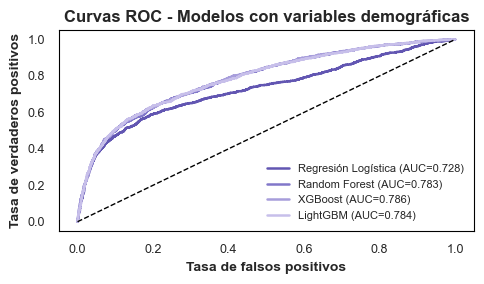

In [ ]:
modelos_roc_con = {
    "Regresión Logística": mejor_regresion_con_demografia,
    "Random Forest": mejor_random_forest_con_demografia,
    "XGBoost": mejor_xgboost_con_demografia,
    "LightGBM": mejor_lightgbm_con_demografia
}

colores = ["#6256B2", "#8177C9", "#A79DDB", "#C7BFEA"]

plt.figure(figsize=(5, 3))

for (nombre, modelo), color in zip(modelos_roc_con.items(), colores):
    probabilidades = modelo.predict_proba(X_test_con)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilidades)
    auc = roc_auc_score(y_test, probabilidades)
    plt.plot(fpr, tpr, linewidth=1.8, color=color, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")

plt.title("Curvas ROC - Modelos con variables demográficas", fontsize=12, fontweight="bold")
plt.xlabel("Tasa de falsos positivos", fontsize=10, fontweight="bold")
plt.ylabel("Tasa de verdaderos positivos", fontsize=10, fontweight="bold")
plt.legend(frameon=False, fontsize=8)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

ax = plt.gca()
ax.grid(False)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.tight_layout()
plt.show()

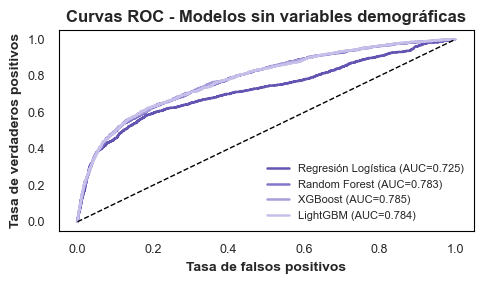

In [ ]:
modelos_roc_sin = {
    "Regresión Logística": mejor_regresion_sin_demografia,
    "Random Forest": mejor_random_forest_sin_demografia,
    "XGBoost": mejor_xgboost_sin_demografia,
    "LightGBM": mejor_lightgbm_sin_demografia
}

plt.figure(figsize=(5, 3))

for (nombre, modelo), color in zip(modelos_roc_sin.items(), colores):
    probabilidades = modelo.predict_proba(X_test_sin)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probabilidades)
    auc = roc_auc_score(y_test, probabilidades)
    plt.plot(fpr, tpr, linewidth=1.8, color=color, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, color="black")

plt.title("Curvas ROC - Modelos sin variables demográficas", fontsize=12, fontweight="bold")
plt.xlabel("Tasa de falsos positivos", fontsize=10, fontweight="bold")
plt.ylabel("Tasa de verdaderos positivos", fontsize=10, fontweight="bold")
plt.legend(frameon=False, fontsize=8)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

ax = plt.gca()
ax.grid(False)

for borde in ax.spines.values():
    borde.set_visible(True)
    borde.set_color("black")
    borde.set_linewidth(0.8)

plt.tight_layout()
plt.show()

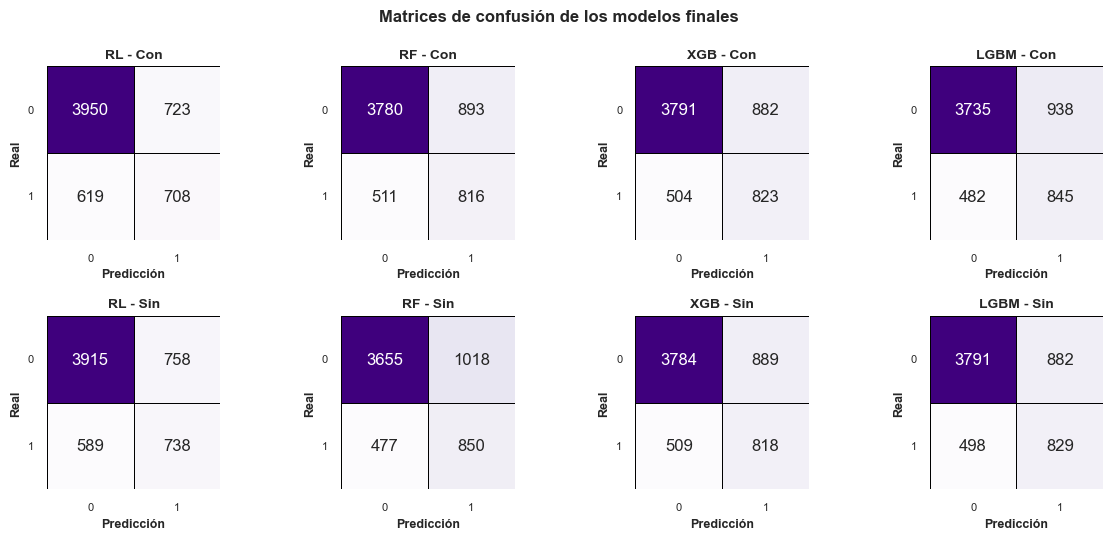

In [ ]:
# Matrices de confusión de los ocho modelos finales
orden_modelos = [
    "Regresión Logística - Con demográficas",
    "Random Forest - Con demográficas",
    "XGBoost - Con demográficas",
    "LightGBM - Con demográficas",
    "Regresión Logística - Sin demográficas",
    "Random Forest - Sin demográficas",
    "XGBoost - Sin demográficas",
    "LightGBM - Sin demográficas"
]

titulos = [
    "RL - Con", "RF - Con", "XGB - Con", "LGBM - Con",
    "RL - Sin", "RF - Sin", "XGB - Sin", "LGBM - Sin"
]

fig, axes = plt.subplots(2, 4, figsize=(12, 5.5))

for ax, nombre, titulo in zip(axes.flatten(), orden_modelos, titulos):
    fila = resultados_test[resultados_test["Modelo"] == nombre].iloc[0]
    matriz = np.array([[fila["TN"], fila["FP"]], [fila["FN"], fila["TP"]]], dtype=int)

    sns.heatmap(matriz, annot=True, fmt="d", cmap="Purples", cbar=False, square=True,
                linewidths=0.5, linecolor="black", ax=ax)

    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicción", fontsize=9, fontweight="bold")
    ax.set_ylabel("Real", fontsize=9, fontweight="bold")
    ax.set_xticklabels(["0", "1"], fontsize=8)
    ax.set_yticklabels(["0", "1"], fontsize=8, rotation=0)

plt.suptitle("Matrices de confusión de los modelos finales", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## **FAIRNESS**

In [ ]:
demograficos_test = demograficos_test.copy()

demograficos_test["GRUPO_EDAD"] = pd.cut(
    demograficos_test["AGE"],
    bins=[20, 29, 39, 49, np.inf],
    labels=["21-29", "30-39", "40-49", "50 o más"])

In [ ]:
# Grupos demográficos evaluados
grupos_sexo = ["Hombre", "Mujer"]
grupos_educacion = ["Posgrado", "Universidad", "Secundaria"]
grupos_estado_civil = ["Casado/a", "Soltero/a"]
grupos_edad = ["21-29", "30-39", "40-49", "50 o más"]

### **SEXO**

In [ ]:
# -------------------------- SEXO -------------------------- #

# Métricas de desempeño por sexo para cada modelo
resultados_sexo = []

for nombre_modelo, (modelo, X_test_modelo) in modelos_finales.items():

    probabilidades = modelo.predict_proba(X_test_modelo)[:, 1]
    threshold = thresholds_finales[nombre_modelo]
    predicciones = (probabilidades >= threshold).astype(int)

    evaluacion = pd.DataFrame({
        "Sexo": demograficos_test["SEX"],
        "Real": y_test,
        "Prediccion": predicciones,
        "Probabilidad": probabilidades
    })

    for sexo in grupos_sexo:

        grupo = evaluacion[evaluacion["Sexo"] == sexo]

        tn, fp, fn, tp = confusion_matrix(grupo["Real"], grupo["Prediccion"], labels=[0, 1]).ravel()

        resultados_sexo.append({
            "Modelo": nombre_modelo,
            "Sexo": sexo,
            "Clientes": len(grupo),
            "Tasa_real": grupo["Real"].mean(),
            "Tasa_predicha": grupo["Prediccion"].mean(),
            "Recall_TPR": tp / (tp + fn),
            "FPR": fp / (fp + tn),
            "Precision": tp / (tp + fp),
            "ROC_AUC": roc_auc_score(grupo["Real"], grupo["Probabilidad"])
        })

resultados_sexo = pd.DataFrame(resultados_sexo)

print(resultados_sexo.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo   Sexo  Clientes  Tasa_real  Tasa_predicha  Recall_TPR    FPR  Precision  ROC_AUC
Regresión Logística - Con demográficas Hombre      2347     0.2416         0.2953      0.5750 0.2062     0.4704   0.7393
Regresión Logística - Con demográficas  Mujer      3653     0.2080         0.2020      0.5026 0.1231     0.5176   0.7153
Regresión Logística - Sin demográficas Hombre      2347     0.2416         0.2744      0.5785 0.1775     0.5093   0.7386
Regresión Logística - Sin demográficas  Mujer      3653     0.2080         0.2332      0.5395 0.1528     0.4812   0.7133
      Random Forest - Con demográficas Hombre      2347     0.2416         0.3183      0.6437 0.2146     0.4886   0.7884
      Random Forest - Con demográficas  Mujer      3653     0.2080         0.2633      0.5934 0.1766     0.4688   0.7782
      Random Forest - Sin demográficas Hombre      2347     0.2416         0.3392      0.6667 0.2348     0.4749   0.7891
      Random Forest - Sin demogr

In [ ]:
# Brechas de equidad entre hombres y mujeres
brechas_sexo = []

for nombre_modelo in modelos_finales:

    resultado_modelo = resultados_sexo[resultados_sexo["Modelo"] == nombre_modelo]

    hombre = resultado_modelo[resultado_modelo["Sexo"] == "Hombre"].iloc[0]
    mujer = resultado_modelo[resultado_modelo["Sexo"] == "Mujer"].iloc[0]

    # Diferencias entre ambos grupos
    brecha_tasa_predicha = hombre["Tasa_predicha"] - mujer["Tasa_predicha"]
    brecha_tpr = hombre["Recall_TPR"] - mujer["Recall_TPR"]
    brecha_fpr = hombre["FPR"] - mujer["FPR"]
    brecha_auc = hombre["ROC_AUC"] - mujer["ROC_AUC"]
    impacto_dispar = hombre["Tasa_predicha"] / mujer["Tasa_predicha"] if mujer["Tasa_predicha"] > 0 else np.nan

    brechas_sexo.append({
        "Modelo": nombre_modelo,
        "Brecha_tasa_predicha": brecha_tasa_predicha,
        "Impacto_dispar": impacto_dispar,
        "Brecha_TPR": brecha_tpr,
        "Brecha_FPR": brecha_fpr,
        "Brecha_AUC": brecha_auc,
        "Equalized_Odds": max(abs(brecha_tpr), abs(brecha_fpr))
    })

brechas_sexo = pd.DataFrame(brechas_sexo).sort_values("Equalized_Odds").reset_index(drop=True)

print(brechas_sexo.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  Brecha_tasa_predicha  Impacto_dispar  Brecha_TPR  Brecha_FPR  Brecha_AUC  Equalized_Odds
Regresión Logística - Sin demográficas                0.0412          1.1765      0.0390      0.0247      0.0253          0.0390
      Random Forest - Sin demográficas                0.0457          1.1557      0.0456      0.0274      0.0118          0.0456
           LightGBM - Sin demográficas                0.0488          1.1834      0.0486      0.0300      0.0117          0.0486
      Random Forest - Con demográficas                0.0549          1.2086      0.0503      0.0380      0.0102          0.0503
            XGBoost - Con demográficas                0.0609          1.2340      0.0503      0.0454      0.0112          0.0503
            XGBoost - Sin demográficas                0.0534          1.2025      0.0538      0.0348      0.0104          0.0538
           LightGBM - Con demográficas                0.0753          1.2811      0.0737      0.0

### **NIVEL EDUCATIVO**

In [ ]:
# --------------------- NIVEL EDUCATIVO --------------------- #

# Métricas de desempeño por nivel educativo para cada modelo
resultados_educacion = []

for nombre_modelo, (modelo, X_test_modelo) in modelos_finales.items():

    probabilidades = modelo.predict_proba(X_test_modelo)[:, 1]
    threshold = thresholds_finales[nombre_modelo]
    predicciones = (probabilidades >= threshold).astype(int)

    evaluacion = pd.DataFrame({
        "Educacion": demograficos_test["EDUCATION"].values,
        "Real": y_test.values,
        "Prediccion": predicciones,
        "Probabilidad": probabilidades
    })

    for educacion in grupos_educacion:

        grupo = evaluacion[evaluacion["Educacion"] == educacion]

        tn, fp, fn, tp = confusion_matrix(grupo["Real"], grupo["Prediccion"], labels=[0, 1]).ravel()

        resultados_educacion.append({
            "Modelo": nombre_modelo,
            "Educacion": educacion,
            "Clientes": len(grupo),
            "Tasa_real": grupo["Real"].mean(),
            "Tasa_predicha": grupo["Prediccion"].mean(),
            "Recall_TPR": tp / (tp + fn),
            "FPR": fp / (fp + tn),
            "Precision": tp / (tp + fp),
            "ROC_AUC": roc_auc_score(grupo["Real"], grupo["Probabilidad"])
        })

resultados_educacion = pd.DataFrame(resultados_educacion)

print(resultados_educacion.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo   Educacion  Clientes  Tasa_real  Tasa_predicha  Recall_TPR    FPR  Precision  ROC_AUC
Regresión Logística - Con demográficas    Posgrado      2163     0.1942         0.1997      0.4690 0.1348     0.4560   0.6981
Regresión Logística - Con demográficas Universidad      2773     0.2297         0.2593      0.5761 0.1648     0.5104   0.7418
Regresión Logística - Con demográficas  Secundaria       964     0.2739         0.2884      0.5417 0.1929     0.5144   0.7186
Regresión Logística - Sin demográficas    Posgrado      2163     0.1942         0.2062      0.4905 0.1377     0.4619   0.6968
Regresión Logística - Sin demográficas Universidad      2773     0.2297         0.2679      0.5965 0.1699     0.5114   0.7398
Regresión Logística - Sin demográficas  Secundaria       964     0.2739         0.3050      0.5682 0.2057     0.5102   0.7201
      Random Forest - Con demográficas    Posgrado      2163     0.1942         0.2386      0.5762 0.1572     0.4690  

In [ ]:
# Brechas de equidad entre los niveles educativos
brechas_educacion = []

for nombre_modelo in modelos_finales:

    resultado_modelo = resultados_educacion[resultados_educacion["Modelo"] == nombre_modelo]
    # Valores máximo y mínimo entre los grupos
    tasa_max = resultado_modelo["Tasa_predicha"].max()
    tasa_min = resultado_modelo["Tasa_predicha"].min()
    
    brecha_tasa_predicha = tasa_max - tasa_min
    brecha_tpr = resultado_modelo["Recall_TPR"].max() - resultado_modelo["Recall_TPR"].min()
    brecha_fpr = resultado_modelo["FPR"].max() - resultado_modelo["FPR"].min()
    brecha_auc = resultado_modelo["ROC_AUC"].max() - resultado_modelo["ROC_AUC"].min()
    impacto_dispar = tasa_max / tasa_min if tasa_min > 0 else np.nan

    brechas_educacion.append({
        "Modelo": nombre_modelo,
        "Brecha_tasa_predicha": brecha_tasa_predicha,
        "Impacto_dispar": impacto_dispar,
        "Brecha_TPR": brecha_tpr,
        "Brecha_FPR": brecha_fpr,
        "Brecha_AUC": brecha_auc,
        "Equalized_Odds": max(brecha_tpr, brecha_fpr)
    })

brechas_educacion = pd.DataFrame(brechas_educacion).sort_values("Equalized_Odds").reset_index(drop=True)

print(brechas_educacion.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  Brecha_tasa_predicha  Impacto_dispar  Brecha_TPR  Brecha_FPR  Brecha_AUC  Equalized_Odds
           LightGBM - Sin demográficas                0.0956          1.3922      0.0389      0.0708      0.0276          0.0708
            XGBoost - Sin demográficas                0.0996          1.4104      0.0525      0.0751      0.0316          0.0751
      Random Forest - Sin demográficas                0.0988          1.3654      0.0339      0.0755      0.0249          0.0755
            XGBoost - Con demográficas                0.1110          1.4654      0.0698      0.0822      0.0337          0.0822
      Random Forest - Con demográficas                0.1131          1.4741      0.0602      0.0871      0.0269          0.0871
           LightGBM - Con demográficas                0.1123          1.4514      0.0578      0.0888      0.0316          0.0888
Regresión Logística - Sin demográficas                0.0988          1.4791      0.1061      0.0

In [ ]:
# Identificación de los grupos con valores máximos y mínimos
extremos_educacion = []

for nombre_modelo in modelos_finales:

    resultado_modelo = resultados_educacion[resultados_educacion["Modelo"] == nombre_modelo]

    extremos_educacion.append({
        "Modelo": nombre_modelo,
        "Mayor_tasa_predicha": resultado_modelo.loc[resultado_modelo["Tasa_predicha"].idxmax(), "Educacion"],
        "Menor_tasa_predicha": resultado_modelo.loc[resultado_modelo["Tasa_predicha"].idxmin(), "Educacion"],
        "Mayor_TPR": resultado_modelo.loc[resultado_modelo["Recall_TPR"].idxmax(), "Educacion"],
        "Menor_TPR": resultado_modelo.loc[resultado_modelo["Recall_TPR"].idxmin(), "Educacion"],
        "Mayor_FPR": resultado_modelo.loc[resultado_modelo["FPR"].idxmax(), "Educacion"],
        "Menor_FPR": resultado_modelo.loc[resultado_modelo["FPR"].idxmin(), "Educacion"],
        "Mayor_AUC": resultado_modelo.loc[resultado_modelo["ROC_AUC"].idxmax(), "Educacion"],
        "Menor_AUC": resultado_modelo.loc[resultado_modelo["ROC_AUC"].idxmin(), "Educacion"]
    })

extremos_educacion = pd.DataFrame(extremos_educacion)

print(extremos_educacion.to_string(index=False))

                                Modelo Mayor_tasa_predicha Menor_tasa_predicha   Mayor_TPR Menor_TPR  Mayor_FPR Menor_FPR   Mayor_AUC  Menor_AUC
Regresión Logística - Con demográficas          Secundaria            Posgrado Universidad  Posgrado Secundaria  Posgrado Universidad   Posgrado
Regresión Logística - Sin demográficas          Secundaria            Posgrado Universidad  Posgrado Secundaria  Posgrado Universidad   Posgrado
      Random Forest - Con demográficas          Secundaria            Posgrado  Secundaria  Posgrado Secundaria  Posgrado    Posgrado Secundaria
      Random Forest - Sin demográficas          Secundaria            Posgrado  Secundaria  Posgrado Secundaria  Posgrado    Posgrado Secundaria
            XGBoost - Con demográficas          Secundaria            Posgrado Universidad  Posgrado Secundaria  Posgrado    Posgrado Secundaria
            XGBoost - Sin demográficas          Secundaria            Posgrado Universidad  Posgrado Secundaria  Posgrado    Posgr

### **ESTADO CIVIL**

In [ ]:
# ------------------------ ESTADO CIVIL ------------------------ #

# Métricas de desempeño por estado civil para cada modelo
resultados_estado_civil = []

for nombre_modelo, (modelo, X_test_modelo) in modelos_finales.items():

    probabilidades = modelo.predict_proba(X_test_modelo)[:, 1]
    threshold = thresholds_finales[nombre_modelo]
    predicciones = (probabilidades >= threshold).astype(int)

    evaluacion = pd.DataFrame({
        "Estado_civil": demograficos_test["MARRIAGE"].values,
        "Real": y_test.values,
        "Prediccion": predicciones,
        "Probabilidad": probabilidades
    })

    for estado_civil in grupos_estado_civil:

        grupo = evaluacion[evaluacion["Estado_civil"] == estado_civil]

        tn, fp, fn, tp = confusion_matrix(grupo["Real"], grupo["Prediccion"], labels=[0, 1]).ravel()

        resultados_estado_civil.append({
            "Modelo": nombre_modelo,
            "Estado_civil": estado_civil,
            "Clientes": len(grupo),
            "Tasa_real": grupo["Real"].mean(),
            "Tasa_predicha": grupo["Prediccion"].mean(),
            "Recall_TPR": tp / (tp + fn),
            "FPR": fp / (fp + tn),
            "Precision": tp / (tp + fp),
            "ROC_AUC": roc_auc_score(grupo["Real"], grupo["Probabilidad"])
        })

resultados_estado_civil = pd.DataFrame(resultados_estado_civil)

print(resultados_estado_civil.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo Estado_civil  Clientes  Tasa_real  Tasa_predicha  Recall_TPR    FPR  Precision  ROC_AUC
Regresión Logística - Con demográficas     Casado/a      2701     0.2414         0.2877      0.5890 0.1918     0.4942   0.7423
Regresión Logística - Con demográficas    Soltero/a      3235     0.2043         0.1954      0.4796 0.1224     0.5016   0.7149
Regresión Logística - Sin demográficas     Casado/a      2701     0.2414         0.2506      0.5675 0.1498     0.5465   0.7407
Regresión Logística - Sin demográficas    Soltero/a      3235     0.2043         0.2482      0.5477 0.1713     0.4508   0.7138
      Random Forest - Con demográficas     Casado/a      2701     0.2414         0.3021      0.6288 0.1981     0.5025   0.7847
      Random Forest - Con demográficas    Soltero/a      3235     0.2043         0.2717      0.6067 0.1857     0.4562   0.7833
      Random Forest - Sin demográficas     Casado/a      2701     0.2414         0.3195      0.6472 0.2152     

In [ ]:
# Brechas de equidad entre casados/as y solteros/as

brechas_estado_civil = []

for nombre_modelo in modelos_finales:

    resultado_modelo = resultados_estado_civil[resultados_estado_civil["Modelo"] == nombre_modelo]

    casado = resultado_modelo[resultado_modelo["Estado_civil"] == "Casado/a"].iloc[0]
    soltero = resultado_modelo[resultado_modelo["Estado_civil"] == "Soltero/a"].iloc[0]
    # Diferencias entre ambos grupos
    brecha_tasa_predicha = casado["Tasa_predicha"] - soltero["Tasa_predicha"]
    brecha_tpr = casado["Recall_TPR"] - soltero["Recall_TPR"]
    brecha_fpr = casado["FPR"] - soltero["FPR"]
    brecha_auc = casado["ROC_AUC"] - soltero["ROC_AUC"]
    impacto_dispar = casado["Tasa_predicha"] / soltero["Tasa_predicha"] if soltero["Tasa_predicha"] > 0 else np.nan

    brechas_estado_civil.append({
        "Modelo": nombre_modelo,
        "Brecha_tasa_predicha": brecha_tasa_predicha,
        "Impacto_dispar": impacto_dispar,
        "Brecha_TPR": brecha_tpr,
        "Brecha_FPR": brecha_fpr,
        "Brecha_AUC": brecha_auc,
        "Equalized_Odds": max(abs(brecha_tpr), abs(brecha_fpr))
    })

brechas_estado_civil = pd.DataFrame(brechas_estado_civil).sort_values("Equalized_Odds").reset_index(drop=True)

print(brechas_estado_civil.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  Brecha_tasa_predicha  Impacto_dispar  Brecha_TPR  Brecha_FPR  Brecha_AUC  Equalized_Odds
           LightGBM - Sin demográficas                0.0145          1.0520      0.0056     -0.0038      0.0012          0.0056
      Random Forest - Sin demográficas                0.0132          1.0430      0.0073     -0.0054      0.0013          0.0073
            XGBoost - Sin demográficas                0.0133          1.0478      0.0192     -0.0088      0.0043          0.0192
Regresión Logística - Sin demográficas                0.0024          1.0098      0.0198     -0.0215      0.0269          0.0215
      Random Forest - Con demográficas                0.0304          1.1119      0.0222      0.0124      0.0014          0.0222
            XGBoost - Con demográficas                0.0489          1.1864      0.0558      0.0263      0.0046          0.0558
           LightGBM - Con demográficas                0.0505          1.1842      0.0560      0.0

### **EDAD**

In [ ]:
# --------------------------- EDAD --------------------------- #

# Métricas de desempeño por grupo de edad para cada modelo
resultados_edad = []

for nombre_modelo, (modelo, X_test_modelo) in modelos_finales.items():

    probabilidades = modelo.predict_proba(X_test_modelo)[:, 1]
    threshold = thresholds_finales[nombre_modelo]
    predicciones = (probabilidades >= threshold).astype(int)

    evaluacion = pd.DataFrame({
        "Grupo_edad": demograficos_test["GRUPO_EDAD"].values,
        "Real": y_test.values,
        "Prediccion": predicciones,
        "Probabilidad": probabilidades
    })

    for grupo_edad in grupos_edad:

        grupo = evaluacion[evaluacion["Grupo_edad"] == grupo_edad]

        tn, fp, fn, tp = confusion_matrix(grupo["Real"], grupo["Prediccion"], labels=[0, 1]).ravel()

        resultados_edad.append({
            "Modelo": nombre_modelo,
            "Grupo_edad": grupo_edad,
            "Clientes": len(grupo),
            "Tasa_real": grupo["Real"].mean(),
            "Tasa_predicha": grupo["Prediccion"].mean(),
            "Recall_TPR": tp / (tp + fn),
            "FPR": fp / (fp + tn),
            "Precision": tp / (tp + fp),
            "ROC_AUC": roc_auc_score(grupo["Real"], grupo["Probabilidad"])
        })

resultados_edad = pd.DataFrame(resultados_edad)

print(resultados_edad.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo Grupo_edad  Clientes  Tasa_real  Tasa_predicha  Recall_TPR    FPR  Precision  ROC_AUC
Regresión Logística - Con demográficas      21-29      1905     0.2105         0.2189      0.5162 0.1396     0.4964   0.7259
Regresión Logística - Con demográficas      30-39      2304     0.2166         0.2209      0.4970 0.1446     0.4872   0.7195
Regresión Logística - Con demográficas      40-49      1241     0.2297         0.2611      0.5754 0.1674     0.5062   0.7571
Regresión Logística - Con demográficas   50 o más       550     0.2582         0.3291      0.6268 0.2255     0.4917   0.7162
Regresión Logística - Sin demográficas      21-29      1905     0.2105         0.2761      0.5860 0.1935     0.4468   0.7239
Regresión Logística - Sin demográficas      30-39      2304     0.2166         0.2339      0.5311 0.1518     0.4917   0.7156
Regresión Logística - Sin demográficas      40-49      1241     0.2297         0.2369      0.5544 0.1423     0.5374   0.7600


In [ ]:
# Brechas de equidad entre los grupos de edad
brechas_edad = []

for nombre_modelo in modelos_finales:

    resultado_modelo = resultados_edad[resultados_edad["Modelo"] == nombre_modelo]
    # Valores máximo y mínimo entre los grupos
    tasa_max = resultado_modelo["Tasa_predicha"].max()
    tasa_min = resultado_modelo["Tasa_predicha"].min()

    brecha_tasa_predicha = tasa_max - tasa_min
    brecha_tpr = resultado_modelo["Recall_TPR"].max() - resultado_modelo["Recall_TPR"].min()
    brecha_fpr = resultado_modelo["FPR"].max() - resultado_modelo["FPR"].min()
    brecha_auc = resultado_modelo["ROC_AUC"].max() - resultado_modelo["ROC_AUC"].min()
    impacto_dispar = tasa_max / tasa_min if tasa_min > 0 else np.nan

    brechas_edad.append({
        "Modelo": nombre_modelo,
        "Brecha_tasa_predicha": brecha_tasa_predicha,
        "Impacto_dispar": impacto_dispar,
        "Brecha_TPR": brecha_tpr,
        "Brecha_FPR": brecha_fpr,
        "Brecha_AUC": brecha_auc,
        "Equalized_Odds": max(brecha_tpr, brecha_fpr)
    })

brechas_edad = pd.DataFrame(brechas_edad).sort_values("Equalized_Odds").reset_index(drop=True)

print(brechas_edad.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  Brecha_tasa_predicha  Impacto_dispar  Brecha_TPR  Brecha_FPR  Brecha_AUC  Equalized_Odds
            XGBoost - Sin demográficas                0.0315          1.1158      0.0286      0.0295      0.0215          0.0295
           LightGBM - Sin demográficas                0.0409          1.1517      0.0407      0.0301      0.0204          0.0407
      Random Forest - Sin demográficas                0.0410          1.1370      0.0427      0.0304      0.0229          0.0427
Regresión Logística - Sin demográficas                0.0422          1.1803      0.0550      0.0538      0.0479          0.0550
      Random Forest - Con demográficas                0.0641          1.2385      0.0838      0.0345      0.0247          0.0838
            XGBoost - Con demográficas                0.0925          1.3504      0.1110      0.0624      0.0218          0.1110
Regresión Logística - Con demográficas                0.1102          1.5034      0.1298      0.0

In [ ]:
# Identificación de los grupos de edad con valores máximos y mínimos
extremos_edad = []

for nombre_modelo in modelos_finales:

    resultado_modelo = resultados_edad[resultados_edad["Modelo"] == nombre_modelo]

    extremos_edad.append({
        "Modelo": nombre_modelo,
        "Mayor_tasa_predicha": resultado_modelo.loc[resultado_modelo["Tasa_predicha"].idxmax(), "Grupo_edad"],
        "Menor_tasa_predicha": resultado_modelo.loc[resultado_modelo["Tasa_predicha"].idxmin(), "Grupo_edad"],
        "Mayor_TPR": resultado_modelo.loc[resultado_modelo["Recall_TPR"].idxmax(), "Grupo_edad"],
        "Menor_TPR": resultado_modelo.loc[resultado_modelo["Recall_TPR"].idxmin(), "Grupo_edad"],
        "Mayor_FPR": resultado_modelo.loc[resultado_modelo["FPR"].idxmax(), "Grupo_edad"],
        "Menor_FPR": resultado_modelo.loc[resultado_modelo["FPR"].idxmin(), "Grupo_edad"],
        "Mayor_AUC": resultado_modelo.loc[resultado_modelo["ROC_AUC"].idxmax(), "Grupo_edad"],
        "Menor_AUC": resultado_modelo.loc[resultado_modelo["ROC_AUC"].idxmin(), "Grupo_edad"]
    })

extremos_edad = pd.DataFrame(extremos_edad)

print(extremos_edad.to_string(index=False))

                                Modelo Mayor_tasa_predicha Menor_tasa_predicha Mayor_TPR Menor_TPR Mayor_FPR Menor_FPR Mayor_AUC Menor_AUC
Regresión Logística - Con demográficas            50 o más               21-29  50 o más     30-39  50 o más     21-29     40-49  50 o más
Regresión Logística - Sin demográficas               21-29               30-39     21-29     30-39     21-29  50 o más     40-49  50 o más
      Random Forest - Con demográficas            50 o más               30-39  50 o más     30-39  50 o más     30-39  50 o más     30-39
      Random Forest - Sin demográficas            50 o más               30-39  50 o más     30-39     21-29     40-49  50 o más     21-29
            XGBoost - Con demográficas            50 o más               30-39  50 o más     30-39  50 o más     30-39  50 o más     21-29
            XGBoost - Sin demográficas            50 o más               30-39  50 o más     30-39     21-29     40-49     40-49     21-29
           LightGBM - Con d

### **RESUMEN FAIRNESS**

In [ ]:
# Consolidación del Equalized Odds para los cuatro atributos demográfico
resumen_global_fairness = brechas_sexo[["Modelo", "Equalized_Odds"]].rename(columns={"Equalized_Odds": "EO_Sexo"})

resumen_global_fairness = resumen_global_fairness.merge(
    brechas_educacion[["Modelo", "Equalized_Odds"]].rename(columns={"Equalized_Odds": "EO_Educacion"}),
    on="Modelo")

resumen_global_fairness = resumen_global_fairness.merge(
    brechas_estado_civil[["Modelo", "Equalized_Odds"]].rename(columns={"Equalized_Odds": "EO_Estado_civil"}),
    on="Modelo")

resumen_global_fairness = resumen_global_fairness.merge(
    brechas_edad[["Modelo", "Equalized_Odds"]].rename(columns={"Equalized_Odds": "EO_Edad"}),
    on="Modelo")

resumen_global_fairness["Promedio_EO"] = resumen_global_fairness[["EO_Sexo", "EO_Educacion", "EO_Estado_civil", "EO_Edad"]].mean(axis=1)
resumen_global_fairness["Maximo_EO"] = resumen_global_fairness[["EO_Sexo", "EO_Educacion", "EO_Estado_civil", "EO_Edad"]].max(axis=1)

resumen_global_fairness = resumen_global_fairness.sort_values("Promedio_EO").reset_index(drop=True)

print(resumen_global_fairness.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  EO_Sexo  EO_Educacion  EO_Estado_civil  EO_Edad  Promedio_EO  Maximo_EO
           LightGBM - Sin demográficas   0.0486        0.0708           0.0056   0.0407       0.0414     0.0708
      Random Forest - Sin demográficas   0.0456        0.0755           0.0073   0.0427       0.0428     0.0755
            XGBoost - Sin demográficas   0.0538        0.0751           0.0192   0.0295       0.0444     0.0751
Regresión Logística - Sin demográficas   0.0390        0.1061           0.0215   0.0550       0.0554     0.1061
      Random Forest - Con demográficas   0.0503        0.0871           0.0222   0.0838       0.0609     0.0871
            XGBoost - Con demográficas   0.0503        0.0822           0.0558   0.1110       0.0748     0.1110
           LightGBM - Con demográficas   0.0737        0.0888           0.0560   0.1382       0.0892     0.1382
Regresión Logística - Con demográficas   0.0831        0.1071           0.1094   0.1298       0.1073    

In [ ]:
# Comparación de Equalized Odds con y sin variables demográficas
comparacion_fairness = []

for algoritmo in ["Regresión Logística", "Random Forest", "XGBoost", "LightGBM"]:

    con = resumen_global_fairness[resumen_global_fairness["Modelo"] == f"{algoritmo} - Con demográficas"].iloc[0]
    sin = resumen_global_fairness[resumen_global_fairness["Modelo"] == f"{algoritmo} - Sin demográficas"].iloc[0]

    comparacion_fairness.append({
        "Algoritmo": algoritmo,
        "Reduccion_Sexo": con["EO_Sexo"] - sin["EO_Sexo"],
        "Reduccion_Educacion": con["EO_Educacion"] - sin["EO_Educacion"],
        "Reduccion_Estado_civil": con["EO_Estado_civil"] - sin["EO_Estado_civil"],
        "Reduccion_Edad": con["EO_Edad"] - sin["EO_Edad"],
        "Reduccion_promedio": con["Promedio_EO"] - sin["Promedio_EO"]
    })

comparacion_fairness = pd.DataFrame(comparacion_fairness).sort_values("Reduccion_promedio", ascending=False).reset_index(drop=True)

print(comparacion_fairness.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

          Algoritmo  Reduccion_Sexo  Reduccion_Educacion  Reduccion_Estado_civil  Reduccion_Edad  Reduccion_promedio
Regresión Logística          0.0441               0.0010                  0.0879          0.0748              0.0520
           LightGBM          0.0251               0.0180                  0.0504          0.0976              0.0478
            XGBoost         -0.0035               0.0072                  0.0366          0.0815              0.0304
      Random Forest          0.0047               0.0115                  0.0149          0.0411              0.0181


In [ ]:
def calcular_equalized_odds(datos, variable, grupos):

    tpr_grupos = []
    fpr_grupos = []

    for grupo_nombre in grupos:

        grupo = datos[datos[variable] == grupo_nombre]

        tn, fp, fn, tp = confusion_matrix(grupo["Real"], grupo["Prediccion"], labels=[0, 1]).ravel()
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)

        tpr_grupos.append(tpr)
        fpr_grupos.append(fpr)

    brecha_tpr = max(tpr_grupos) - min(tpr_grupos)
    brecha_fpr = max(fpr_grupos) - min(fpr_grupos)

    return max(brecha_tpr, brecha_fpr)

## **COMPARACION ENTRE EQUIDAD Y DESEMPEÑO**

In [ ]:
# Integración del desempeño predictivo con el resumen de equidad
comparacion_desempeno_equidad = resultados_test[["Modelo", "ROC_AUC"]].merge(resumen_global_fairness[["Modelo", "Promedio_EO", "Maximo_EO"]], on="Modelo")

comparacion_desempeno_equidad = comparacion_desempeno_equidad.sort_values(["Promedio_EO", "ROC_AUC"],ascending=[True, False]).reset_index(drop=True)

print(comparacion_desempeno_equidad.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo  ROC_AUC  Promedio_EO  Maximo_EO
           LightGBM - Sin demográficas   0.7843       0.0414     0.0708
      Random Forest - Sin demográficas   0.7831       0.0428     0.0755
            XGBoost - Sin demográficas   0.7849       0.0444     0.0751
Regresión Logística - Sin demográficas   0.7250       0.0554     0.1061
      Random Forest - Con demográficas   0.7835       0.0609     0.0871
            XGBoost - Con demográficas   0.7863       0.0748     0.1110
           LightGBM - Con demográficas   0.7844       0.0892     0.1382
Regresión Logística - Con demográficas   0.7277       0.1073     0.1298


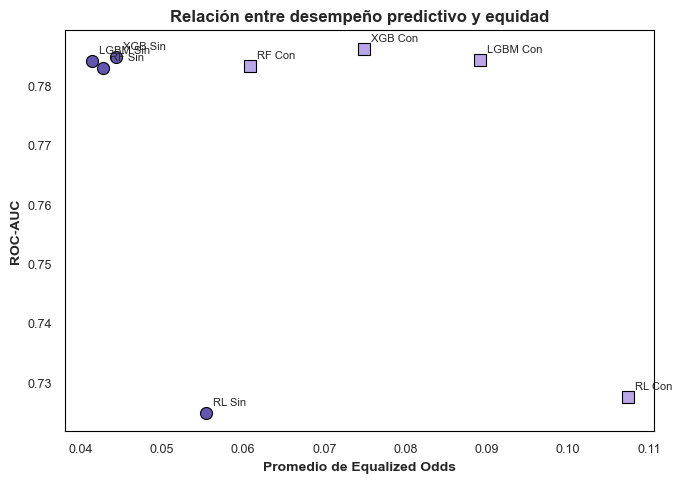

In [ ]:
plt.figure(figsize=(7, 5))

for _, fila in comparacion_desempeno_equidad.iterrows():

    if "Sin demográficas" in fila["Modelo"]:
        color = "#6256B2"
        marcador = "o"
    else:
        color = "#B9A7E8"
        marcador = "s"

    plt.scatter(fila["Promedio_EO"], fila["ROC_AUC"], s=75, color=color, marker=marcador, edgecolor="black", linewidth=0.8)

    nombre = (
        fila["Modelo"]
        .replace("Regresión Logística", "RL")
        .replace("Random Forest", "RF")
        .replace("XGBoost", "XGB")
        .replace("LightGBM", "LGBM")
        .replace(" - Con demográficas", " Con")
        .replace(" - Sin demográficas", " Sin")
    )

    plt.annotate(nombre, (fila["Promedio_EO"], fila["ROC_AUC"]), xytext=(5, 5), textcoords="offset points", fontsize=8)

plt.xlabel("Promedio de Equalized Odds", fontsize=10, fontweight="bold")
plt.ylabel("ROC-AUC", fontsize=10, fontweight="bold")
plt.title("Relación entre desempeño predictivo y equidad", fontsize=12, fontweight="bold")

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

In [ ]:
# Comparación del cambio en desempeño y equidad al excluir las demográficas
cambio_desempeno_equidad = []

for algoritmo in ["Regresión Logística", "Random Forest", "XGBoost", "LightGBM"]:

    con = comparacion_desempeno_equidad[comparacion_desempeno_equidad["Modelo"] == f"{algoritmo} - Con demográficas"].iloc[0]
    sin = comparacion_desempeno_equidad[comparacion_desempeno_equidad["Modelo"] == f"{algoritmo} - Sin demográficas"].iloc[0]

    cambio_desempeno_equidad.append({
        "Algoritmo": algoritmo,
        "AUC_con": con["ROC_AUC"],
        "AUC_sin": sin["ROC_AUC"],
        "Diferencia_AUC": con["ROC_AUC"] - sin["ROC_AUC"],
        "EO_promedio_con": con["Promedio_EO"],
        "EO_promedio_sin": sin["Promedio_EO"],
        "Reduccion_EO": con["Promedio_EO"] - sin["Promedio_EO"]
    })

cambio_desempeno_equidad = pd.DataFrame(cambio_desempeno_equidad)

print(cambio_desempeno_equidad.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

          Algoritmo  AUC_con  AUC_sin  Diferencia_AUC  EO_promedio_con  EO_promedio_sin  Reduccion_EO
Regresión Logística   0.7277   0.7250          0.0027           0.1073           0.0554        0.0520
      Random Forest   0.7835   0.7831          0.0004           0.0609           0.0428        0.0181
            XGBoost   0.7863   0.7849          0.0014           0.0748           0.0444        0.0304
           LightGBM   0.7844   0.7843          0.0002           0.0892           0.0414        0.0478


## **ANALISIS DE SENSIBILIDAD**

In [ ]:
# Probabilidades estimadas sobre test para los ocho modelos
probabilidades_sensibilidad = {}

for nombre_modelo, (modelo, X_test_modelo) in modelos_finales.items():
    probabilidades_sensibilidad[nombre_modelo] = modelo.predict_proba(X_test_modelo)[:, 1]

print("Probabilidades preparadas para los 8 modelos.")

Probabilidades preparadas para los 8 modelos.


In [ ]:
# Umbrales evaluados y grupos demográficos analizados
thresholds_sensibilidad = np.arange(0.10, 0.51, 0.01)

atributos_sensibilidad = {
    "Sexo": ("SEX", ["Hombre", "Mujer"]),
    "Educacion": ("EDUCATION", ["Posgrado", "Universidad", "Secundaria"]),
    "Estado_civil": ("MARRIAGE", ["Casado/a", "Soltero/a"]),
    "Edad": ("GRUPO_EDAD", ["21-29", "30-39", "40-49", "50 o más"])
}

In [ ]:
# Cálculo de las brechas de TPR, FPR y Equalized Odds para un umbral
def calcular_brechas_threshold(real, prediccion, grupos_demograficos, grupos):

    tpr_grupos = []
    fpr_grupos = []

    for grupo_nombre in grupos:
        mascara = grupos_demograficos == grupo_nombre

        tn, fp, fn, tp = confusion_matrix(real[mascara], prediccion[mascara], labels=[0, 1]).ravel()
        tpr = tp / (tp + fn)
        fpr = fp / (fp + tn)
        tpr_grupos.append(tpr)
        fpr_grupos.append(fpr)

    brecha_tpr = max(tpr_grupos) - min(tpr_grupos)
    brecha_fpr = max(fpr_grupos) - min(fpr_grupos)
    equalized_odds = max(brecha_tpr, brecha_fpr)

    return brecha_tpr, brecha_fpr, equalized_odds

In [ ]:
# Evaluación de Equalized Odds a través de los distintos umbrales
resultados_sensibilidad = []

for nombre_modelo, probabilidades in probabilidades_sensibilidad.items():

    for threshold in thresholds_sensibilidad:
        predicciones = (probabilidades >= threshold).astype(int)

        for nombre_atributo, (variable, grupos) in atributos_sensibilidad.items():
            brecha_tpr, brecha_fpr, eo = calcular_brechas_threshold(y_test.values, predicciones, demograficos_test[variable].values, grupos)

            resultados_sensibilidad.append({
                "Modelo": nombre_modelo,
                "Atributo": nombre_atributo,
                "Threshold": threshold,
                "Brecha_TPR": brecha_tpr,
                "Brecha_FPR": brecha_fpr,
                "Equalized_Odds": eo
            })

resultados_sensibilidad = pd.DataFrame(resultados_sensibilidad)

print(resultados_sensibilidad.head(20).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

                                Modelo     Atributo  Threshold  Brecha_TPR  Brecha_FPR  Equalized_Odds
Regresión Logística - Con demográficas         Sexo     0.1000      0.0602      0.0724          0.0724
Regresión Logística - Con demográficas    Educacion     0.1000      0.0627      0.0965          0.0965
Regresión Logística - Con demográficas Estado_civil     0.1000      0.0200      0.0019          0.0200
Regresión Logística - Con demográficas         Edad     0.1000      0.0531      0.1008          0.1008
Regresión Logística - Con demográficas         Sexo     0.1100      0.0865      0.0893          0.0893
Regresión Logística - Con demográficas    Educacion     0.1100      0.0740      0.1244          0.1244
Regresión Logística - Con demográficas Estado_civil     0.1100      0.0334      0.0123          0.0334
Regresión Logística - Con demográficas         Edad     0.1100      0.0461      0.1030          0.1030
Regresión Logística - Con demográficas         Sexo     0.1200      0.103

In [ ]:
# Comparación CON vs. SIN demográficas para cada umbral
comparacion_thresholds = []

for algoritmo in ["Regresión Logística", "Random Forest", "XGBoost", "LightGBM"]:

    nombre_con = f"{algoritmo} - Con demográficas"
    nombre_sin = f"{algoritmo} - Sin demográficas"

    for atributo in atributos_sensibilidad.keys():

        datos_con = resultados_sensibilidad[(resultados_sensibilidad["Modelo"] == nombre_con) & (resultados_sensibilidad["Atributo"] == atributo)]
        datos_sin = resultados_sensibilidad[(resultados_sensibilidad["Modelo"] == nombre_sin) & (resultados_sensibilidad["Atributo"] == atributo)]

        comparacion = datos_con.merge(datos_sin, on=["Atributo", "Threshold"], suffixes=("_con", "_sin"))

        # Diferencia de EO entre ambos escenarios
        comparacion["Reduccion_EO"] = (comparacion["Equalized_Odds_con"] - comparacion["Equalized_Odds_sin"])

        comparacion["Algoritmo"] = algoritmo

        comparacion_thresholds.append(
            comparacion[
                [
                    "Algoritmo",
                    "Atributo",
                    "Threshold",
                    "Equalized_Odds_con",
                    "Equalized_Odds_sin",
                    "Reduccion_EO"
                ]
            ]
        )

comparacion_thresholds = pd.concat(comparacion_thresholds, ignore_index=True)

print(comparacion_thresholds.head(20).to_string(index=False, float_format=lambda x: f"{x:.4f}"))

          Algoritmo Atributo  Threshold  Equalized_Odds_con  Equalized_Odds_sin  Reduccion_EO
Regresión Logística     Sexo     0.1000              0.0724              0.0396        0.0328
Regresión Logística     Sexo     0.1100              0.0893              0.0452        0.0441
Regresión Logística     Sexo     0.1200              0.1031              0.0626        0.0405
Regresión Logística     Sexo     0.1300              0.1139              0.0796        0.0343
Regresión Logística     Sexo     0.1400              0.1112              0.0782        0.0330
Regresión Logística     Sexo     0.1500              0.1106              0.0785        0.0321
Regresión Logística     Sexo     0.1600              0.0947              0.0701        0.0246
Regresión Logística     Sexo     0.1700              0.1030              0.0709        0.0321
Regresión Logística     Sexo     0.1800              0.1016              0.0673        0.0343
Regresión Logística     Sexo     0.1900              0.1248 

In [ ]:
# Resumen de estabilidad de las diferencias de Equalized Odds
resumen_estabilidad = comparacion_thresholds.groupby(
    ["Algoritmo", "Atributo"]).agg(
    Reduccion_EO_media=("Reduccion_EO", "mean"),
    Reduccion_EO_minima=("Reduccion_EO", "min"),
    Reduccion_EO_maxima=("Reduccion_EO", "max"),
    EO_con_promedio=("Equalized_Odds_con", "mean"),
    EO_sin_promedio=("Equalized_Odds_sin", "mean")).reset_index()

# Porcentaje de umbrales donde SIN demográficas presenta menor EO
porcentaje_mejora = (comparacion_thresholds.assign(Mejora=lambda x: x["Reduccion_EO"] > 0)
    .groupby(["Algoritmo", "Atributo"])["Mejora"].mean().mul(100).reset_index(name="Pct_thresholds_mejora"))

resumen_estabilidad = resumen_estabilidad.merge(porcentaje_mejora, on=["Algoritmo", "Atributo"])

print(resumen_estabilidad.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

          Algoritmo     Atributo  Reduccion_EO_media  Reduccion_EO_minima  Reduccion_EO_maxima  EO_con_promedio  EO_sin_promedio  Pct_thresholds_mejora
           LightGBM         Edad              0.0350              -0.0125               0.1001           0.1230           0.0879                87.8049
           LightGBM    Educacion              0.0042              -0.0241               0.0227           0.1131           0.1089                70.7317
           LightGBM Estado_civil              0.0234              -0.0047               0.0514           0.0462           0.0228                97.5610
           LightGBM         Sexo              0.0247               0.0040               0.0629           0.0682           0.0435               100.0000
      Random Forest         Edad              0.0213              -0.0121               0.0631           0.1044           0.0831                92.6829
      Random Forest    Educacion              0.0092              -0.0134               

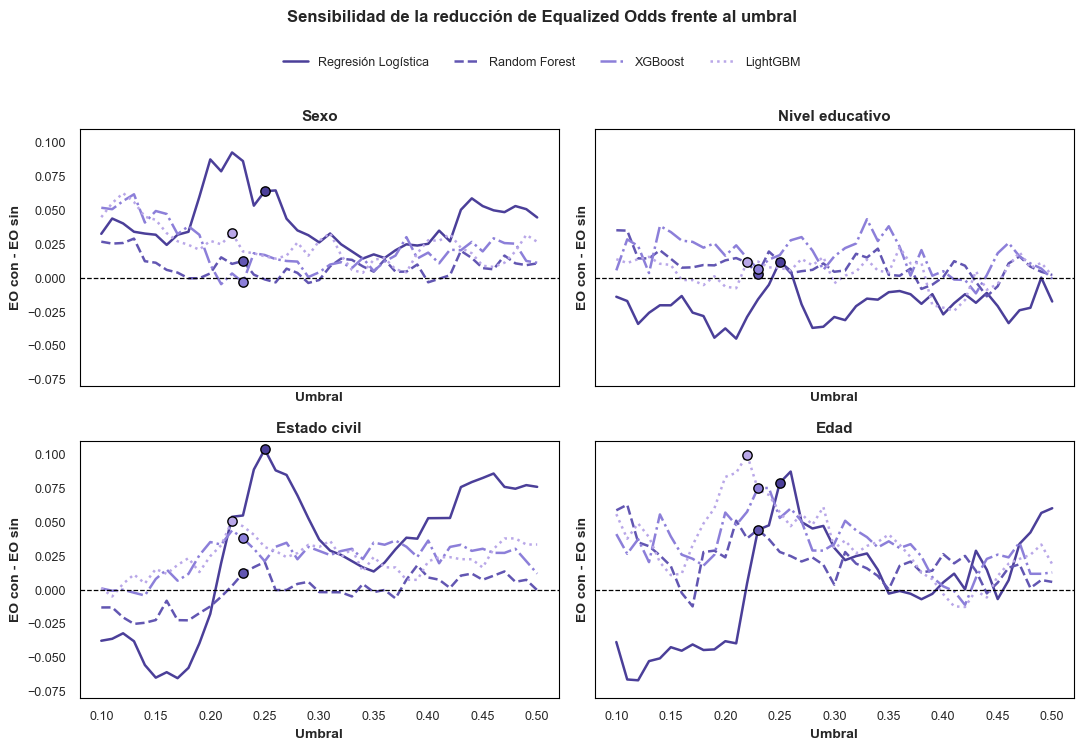

In [ ]:
orden_atributos = ["Sexo", "Educacion", "Estado_civil", "Edad"]
orden_algoritmos = ["Regresión Logística", "Random Forest", "XGBoost", "LightGBM"]

nombres_atributos = {
    "Sexo": "Sexo",
    "Educacion": "Nivel educativo",
    "Estado_civil": "Estado civil",
    "Edad": "Edad"
}

colores = {
    "Regresión Logística": "#4B3F99",
    "Random Forest": "#6256B2",
    "XGBoost": "#8C7FD9",
    "LightGBM": "#B9A7E8"
}

estilos = {
    "Regresión Logística": "-",
    "Random Forest": "--",
    "XGBoost": "-.",
    "LightGBM": ":"
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
axes = axes.flatten()

for i, atributo in enumerate(orden_atributos):

    ax = axes[i]

    datos_atributo = comparacion_thresholds[comparacion_thresholds["Atributo"] == atributo]

    for algoritmo in orden_algoritmos:
        datos_algoritmo = datos_atributo[datos_atributo["Algoritmo"] == algoritmo].sort_values("Threshold")

        ax.plot(datos_algoritmo["Threshold"], datos_algoritmo["Reduccion_EO"],
            label=algoritmo, color=colores[algoritmo], linestyle=estilos[algoritmo], linewidth=1.8)

        # Threshold de Youden del modelo CON y SIN:
        threshold_con = thresholds_finales[f"{algoritmo} - Con demográficas"]
        threshold_sin = thresholds_finales[f"{algoritmo} - Sin demográficas"]
        threshold_referencia = (threshold_con + threshold_sin) / 2

        indice_cercano = (datos_algoritmo["Threshold"] - threshold_referencia).abs().idxmin()
        punto = datos_algoritmo.loc[indice_cercano]

        ax.scatter(punto["Threshold"], punto["Reduccion_EO"], color=colores[algoritmo], edgecolor="black", s=45, zorder=5)

    ax.axhline(0, color="black", linestyle="--", linewidth=0.9)
    ax.set_title(nombres_atributos[atributo], fontsize=11, fontweight="bold")
    ax.set_xlabel("Umbral", fontsize=10, fontweight="bold")
    ax.set_ylabel("EO con - EO sin", fontsize=10, fontweight="bold")

    ax.set_ylim(-0.08, 0.11)
    ax.tick_params(axis="both", labelsize=9)
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False, fontsize=9)
plt.suptitle("Sensibilidad de la reducción de Equalized Odds frente al umbral", fontsize=12, fontweight="bold", y=1.07)

plt.tight_layout()
plt.show()

## **MITIGACIÓN**

In [ ]:
# Creación de los mismos grupos de edad utilizados en la evaluación de fairness
demograficos_train = demograficos_train.copy()

demograficos_train["GRUPO_EDAD"] = pd.cut(
    demograficos_train["AGE"],
    bins=[20, 29, 39, 49, np.inf],
    labels=["21-29", "30-39", "40-49", "50 o más"]
)

print(demograficos_train["GRUPO_EDAD"].value_counts().sort_index())

GRUPO_EDAD
21-29       7713
30-39       8934
40-49       5223
50 o más    2130
Name: count, dtype: int64


In [ ]:
# Probabilidades out-of-fold del XGBoost CON demográficas
validacion_mitigacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

probabilidades_oof_mitigacion = cross_val_predict(mejor_xgboost_con_demografia, X_train_con, y_train,
    cv=validacion_mitigacion, method="predict_proba", n_jobs=-1)[:, 1]

print("Probabilidades OOF obtenidas correctamente.")

Probabilidades OOF obtenidas correctamente.


In [ ]:
# Umbral original seleccionado mediante el criterio de Youden
threshold_base = thresholds_finales["XGBoost - Con demográficas"]

predicciones_base_train = (probabilidades_oof_mitigacion >= threshold_base).astype(int)

balanced_accuracy_base = balanced_accuracy_score(y_train,predicciones_base_train)

print(f"Threshold base: {threshold_base:.4f}")
print(f"Balanced Accuracy base OOF: {balanced_accuracy_base:.4f}")

Threshold base: 0.2299
Balanced Accuracy base OOF: 0.7161


In [ ]:
# ---------------- OPTIMIZACIÓN DE UMBRALES POR EDAD ---------------- #

grupos_edad_mitigacion = ["21-29", "30-39", "40-49", "50 o más"]

grupos_train = demograficos_train["GRUPO_EDAD"].astype(str).values
y_train_array = y_train.values

# Balanced Accuracy mínima permitida
ba_minima = balanced_accuracy_base - 0.02

# Equalized Odds con el umbral general original
datos_base_mitigacion = pd.DataFrame({
    "Real": y_train_array,
    "Prediccion": predicciones_base_train,
    "GRUPO_EDAD": grupos_train
})

eo_base_train = calcular_equalized_odds(datos_base_mitigacion, "GRUPO_EDAD", grupos_edad_mitigacion)

print(f"Equalized Odds base OOF: {eo_base_train:.4f}")
print(f"Balanced Accuracy base OOF: {balanced_accuracy_base:.4f}")
print(f"Balanced Accuracy mínima permitida: {ba_minima:.4f}")

def objetivo_mitigacion(trial):

    thresholds_grupo = {
        "21-29": trial.suggest_float("threshold_21_29", 0.10, 0.50),
        "30-39": trial.suggest_float("threshold_30_39", 0.10, 0.50),
        "40-49": trial.suggest_float("threshold_40_49", 0.10, 0.50),
        "50 o más": trial.suggest_float("threshold_50_mas", 0.10, 0.50)
    }

    predicciones = np.zeros(len(y_train_array), dtype=int)

    for grupo, threshold in thresholds_grupo.items():
        mascara = grupos_train == grupo
        predicciones[mascara] = (
            probabilidades_oof_mitigacion[mascara] >= threshold).astype(int)

    balanced_accuracy = balanced_accuracy_score(y_train_array, predicciones)

    # Penalización si la pérdida de desempeño supera el límite
    if balanced_accuracy < ba_minima:
        return 1 + (ba_minima - balanced_accuracy)

    datos_mitigacion = pd.DataFrame({
        "Real": y_train_array,
        "Prediccion": predicciones,
        "GRUPO_EDAD": grupos_train
    })

    eo = calcular_equalized_odds(datos_mitigacion, "GRUPO_EDAD", grupos_edad_mitigacion)
    return eo

# Optimización mediante Optuna
estudio_mitigacion = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))

# El umbral original se incluye como punto inicial
estudio_mitigacion.enqueue_trial({
    "threshold_21_29": threshold_base,
    "threshold_30_39": threshold_base,
    "threshold_40_49": threshold_base,
    "threshold_50_mas": threshold_base
})

estudio_mitigacion.optimize(objetivo_mitigacion, n_trials=300, show_progress_bar=True)

thresholds_mitigados = estudio_mitigacion.best_params

print("\nMejores thresholds encontrados:")
for grupo, threshold in thresholds_mitigados.items():
    print(f"{grupo}: {threshold:.4f}")

Equalized Odds base OOF: 0.0798
Balanced Accuracy base OOF: 0.7161
Balanced Accuracy mínima permitida: 0.6961


  0%|          | 0/300 [00:00<?, ?it/s]


Mejores thresholds encontrados:
threshold_21_29: 0.2786
threshold_30_39: 0.2413
threshold_40_49: 0.2652
threshold_50_mas: 0.3152


In [ ]:
# Asociación de los umbrales optimizados con cada grupo de edad
mapeo_thresholds = {
    "21-29": thresholds_mitigados["threshold_21_29"],
    "30-39": thresholds_mitigados["threshold_30_39"],
    "40-49": thresholds_mitigados["threshold_40_49"],
    "50 o más": thresholds_mitigados["threshold_50_mas"]
}

# Aplicación de los umbrales por grupo sobre las probabilidades OOF
predicciones_mitigadas_train = np.zeros(len(y_train_array), dtype=int)

for grupo, threshold in mapeo_thresholds.items():
    mascara = grupos_train == grupo
    predicciones_mitigadas_train[mascara] = (probabilidades_oof_mitigacion[mascara] >= threshold).astype(int)

balanced_accuracy_mitigada_train = balanced_accuracy_score(y_train_array, predicciones_mitigadas_train)

# Equalized Odds después de la mitigación
datos_mitigados_train = pd.DataFrame({
    "Real": y_train_array,
    "Prediccion": predicciones_mitigadas_train,
    "GRUPO_EDAD": grupos_train
})

eo_mitigado_train = calcular_equalized_odds(datos_mitigados_train, "GRUPO_EDAD", grupos_edad_mitigacion)

print(f"EO antes de mitigar: {eo_base_train:.4f}")
print(f"EO después de mitigar: {eo_mitigado_train:.4f}")
print(f"Reducción EO: {eo_base_train - eo_mitigado_train:.4f}")

print(f"\nBalanced Accuracy antes: {balanced_accuracy_base:.4f}")
print(f"Balanced Accuracy después: {balanced_accuracy_mitigada_train:.4f}")
print(f"Variación BA: {balanced_accuracy_mitigada_train - balanced_accuracy_base:.4f}")

EO antes de mitigar: 0.0798
EO después de mitigar: 0.0106
Reducción EO: 0.0692

Balanced Accuracy antes: 0.7161
Balanced Accuracy después: 0.7114
Variación BA: -0.0047


In [ ]:
# Probabilidades del XGBoost CON demográficas en test
probabilidades_test_mitigacion = mejor_xgboost_con_demografia.predict_proba(X_test_con)[:, 1]

threshold_base = thresholds_finales["XGBoost - Con demográficas"]

# Predicciones antes de la mitigación
predicciones_base_test = (probabilidades_test_mitigacion >= threshold_base).astype(int)

# Predicciones mitigadas con umbrales diferentes por grupo de edad
grupos_test = demograficos_test["GRUPO_EDAD"].astype(str).values

predicciones_mitigadas_test = np.zeros(len(y_test), dtype=int)

for grupo, threshold in mapeo_thresholds.items():

    mascara = grupos_test == grupo

    predicciones_mitigadas_test[mascara] = (probabilidades_test_mitigacion[mascara] >= threshold).astype(int)


resultados_mitigacion = []

for escenario, predicciones in {
    "Antes de mitigar": predicciones_base_test,
    "Después de mitigar": predicciones_mitigadas_test
}.items():

    resultados_mitigacion.append({
        "Escenario": escenario,
        "ROC_AUC": roc_auc_score(y_test, probabilidades_test_mitigacion),
        "Recall": recall_score(y_test, predicciones),
        "Precision": precision_score(y_test, predicciones),
        "F1": f1_score(y_test, predicciones),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, predicciones)
    })

resultados_mitigacion = pd.DataFrame(resultados_mitigacion)

print(resultados_mitigacion.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

         Escenario  ROC_AUC  Recall  Precision     F1  Balanced_Accuracy
  Antes de mitigar   0.7863  0.6202     0.4827 0.5429             0.7157
Después de mitigar   0.7863  0.5772     0.5239 0.5493             0.7142


In [ ]:
# Comparación de Equalized Odds por edad antes y después de la mitigación
datos_base_test = pd.DataFrame({
    "Real": y_test.values,
    "Prediccion": predicciones_base_test,
    "GRUPO_EDAD": grupos_test
})

datos_mitigados_test = pd.DataFrame({
    "Real": y_test.values,
    "Prediccion": predicciones_mitigadas_test,
    "GRUPO_EDAD": grupos_test
})

eo_base_test = calcular_equalized_odds(datos_base_test, "GRUPO_EDAD", grupos_edad_mitigacion)
eo_mitigado_test = calcular_equalized_odds(datos_mitigados_test, "GRUPO_EDAD", grupos_edad_mitigacion)

print(f"Equalized Odds antes: {eo_base_test:.4f}")
print(f"Equalized Odds después: {eo_mitigado_test:.4f}")
print(f"Reducción de EO: {eo_base_test - eo_mitigado_test:.4f}")
print(f"Reducción porcentual: {(eo_base_test - eo_mitigado_test) / eo_base_test * 100:.2f}%")

Equalized Odds antes: 0.1110
Equalized Odds después: 0.0594
Reducción de EO: 0.0516
Reducción porcentual: 46.50%


In [ ]:
# Métricas por grupo de edad antes y después de la mitigación
resultados_grupos_mitigacion = []

for escenario, predicciones in {
    "Antes": predicciones_base_test,
    "Después": predicciones_mitigadas_test
}.items():

    for grupo in grupos_edad_mitigacion:

        mascara = grupos_test == grupo

        tn, fp, fn, tp = confusion_matrix(y_test.values[mascara], predicciones[mascara], labels=[0, 1]).ravel()

        resultados_grupos_mitigacion.append({
            "Escenario": escenario,
            "Grupo_edad": grupo,
            "Clientes": mascara.sum(),
            "TPR": tp / (tp + fn),
            "FPR": fp / (fp + tn)
        })

resultados_grupos_mitigacion = pd.DataFrame(resultados_grupos_mitigacion)

print(resultados_grupos_mitigacion.to_string( index=False, float_format=lambda x: f"{x:.4f}"))

Escenario Grupo_edad  Clientes    TPR    FPR
    Antes      21-29      1905 0.6185 0.1922
    Antes      30-39      2304 0.5932 0.1729
    Antes      40-49      1241 0.6281 0.1935
    Antes   50 o más       550 0.7042 0.2353
  Después      21-29      1905 0.5511 0.1396
  Después      30-39      2304 0.5752 0.1584
  Después      40-49      1241 0.6105 0.1506
  Después   50 o más       550 0.5915 0.1373


In [ ]:
probabilidades_xgb_sin = mejor_xgboost_sin_demografia.predict_proba(X_test_sin)[:, 1]
threshold_xgb_sin = thresholds_finales["XGBoost - Sin demográficas"]
predicciones_xgb_sin = (probabilidades_xgb_sin >= threshold_xgb_sin).astype(int)

def equalized_odds_edad(predicciones):

    datos = pd.DataFrame({
        "Real": y_test.values,
        "Prediccion": predicciones,
        "GRUPO_EDAD": demograficos_test["GRUPO_EDAD"].astype(str).values
    })

    return calcular_equalized_odds(datos, "GRUPO_EDAD", grupos_edad_mitigacion)

comparacion_mitigacion = []

escenarios = {
    "XGBoost CON - Original": (probabilidades_test_mitigacion, predicciones_base_test),
    "XGBoost CON - Post-processing": (probabilidades_test_mitigacion, predicciones_mitigadas_test),
    "XGBoost SIN demográficas": (probabilidades_xgb_sin, predicciones_xgb_sin)}

for nombre, (probabilidades, predicciones) in escenarios.items():

    comparacion_mitigacion.append({
        "Escenario": nombre,
        "ROC_AUC": roc_auc_score(y_test, probabilidades),
        "Recall": recall_score(y_test, predicciones),
        "Precision": precision_score(y_test, predicciones),
        "F1": f1_score(y_test, predicciones),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, predicciones),
        "Equalized_Odds_Edad": equalized_odds_edad(predicciones)
    })

comparacion_mitigacion = pd.DataFrame(comparacion_mitigacion)

print(comparacion_mitigacion.to_string( index=False, float_format=lambda x: f"{x:.4f}"))

                    Escenario  ROC_AUC  Recall  Precision     F1  Balanced_Accuracy  Equalized_Odds_Edad
       XGBoost CON - Original   0.7863  0.6202     0.4827 0.5429             0.7157               0.1110
XGBoost CON - Post-processing   0.7863  0.5772     0.5239 0.5493             0.7142               0.0594
     XGBoost SIN demográficas   0.7849  0.6164     0.4792 0.5392             0.7131               0.0295
